In [1]:
## set working directory
import os
os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")

In [2]:
## load required packages
from dill.temp import b
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX path:", jax.__file__)

## load module
import sys

bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/illegal-dumping-nov12-2025/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/Elena/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/BSTPP')
sys.path.insert(0, bstpp_module_dir)
import bstpp

import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import geopandas as gpd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
#!pip install torch
import torch
from shapely.geometry import box
import contextily as ctx ## for basemap
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates 
import calendar
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from shapely.geometry import Point ## for spatial jittering
import osmnx as ox
import shapely.geometry as geom
from scipy.stats import lomax
from collections import defaultdict
from statistics import mean, median
# from tqdm import tqdm
from tqdm.notebook import tqdm
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from datetime import datetime
import shapely
import json


np.random.seed(999)

import importlib
importlib.reload(bstpp)

from bstpp.main import Hawkes_Model
#from bstpp.trigger import Temporal_Power_Law, simulate_hawkes_like_events,plot_inter_arrival_distribution
from bstpp.trigger import Temporal_Power_Law

#from bstpp.cox_hawkes_latent import Cox_Hawkes_Latent, prepare_litter_and_reporting_args

from bstpp.cox_hawkes_shared import Cox_Hawkes_Shared, attach_litter_survey_args, attach_dumping_report_args, plot_dumping_report_regression


JAX path: /Users/yuxin/miniconda3/lib/python3.12/site-packages/jax/__init__.py


In [3]:
## set working directory
#import os
#os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")

## Loadding shapefiles for plotting

### CBG border and Land care data

In [3]:
# load philly cbg border
pa_2023 = gpd.read_file('data/tiger/tl_2023_42_bg/tl_2023_42_bg.shp')
philly_2023 = pa_2023[pa_2023['COUNTYFP']=='101']
philly_2023 = philly_2023.to_crs(epsg=26918)

In [4]:
## load land care data
land_care = gpd.read_file('data/Land_Care/phs_landcare.geojson')

land_care['year'] = pd.to_numeric(land_care['year'], errors='coerce')

## Filter for years between 2021 and 2025
land_care_21_25= land_care[(land_care['year'] >= 2021) & (land_care['year'] <= 2025)]

land_care_21_25 = land_care_21_25.to_crs(epsg=26918)

### Land Use

In [5]:
## load land use data
land_use_current = gpd.read_file('data/Land_Use/Land_use.geojson')

## recategorize land use types
land_use_current['type'] = pd.Series(dtype='object')

# residential
land_use_current.loc[(land_use_current['c_dig2'] == 11),'type'] = "Res Low Den"
land_use_current.loc[(land_use_current['c_dig2'] == 12),'type'] = "Res Med Den"
land_use_current.loc[(land_use_current['c_dig2'] == 13),'type'] = "Res High Den"
# commercial
land_use_current.loc[
    (land_use_current['c_dig2'] == 21) | (land_use_current['c_dig2'] == 22)|(land_use_current['c_dig2'] == 23),
    'type'
] = "Commercial"
# civic 
land_use_current.loc[
    (land_use_current['c_dig2'] == 41) | (land_use_current['c_dig2'] == 61)|(land_use_current['c_dig2'] == 62)|(land_use_current['c_dig2'] == 71)|(land_use_current['c_dig2'] == 72),
    'type'
] = "Civic"
# other
land_use_current.loc[(land_use_current['c_dig2'] == 31),'type'] = "Industry"
land_use_current.loc[(land_use_current['c_dig2'] == 51),'type'] = "Transportation"
land_use_current.loc[(land_use_current['c_dig2'] == 51),'type'] = "Green ROW"
land_use_current.loc[(land_use_current['c_dig2'] == 81),'type'] = "Water"
land_use_current.loc[(land_use_current['c_dig2'] == 91),'type'] = "Vacant"
land_use_current.loc[(land_use_current['c_dig2'] == 92),'type'] = "Other"

In [6]:
## Customize color map for land use categories
use_lst = ['Res Low Den', 'Res Med Den', 'Res High Den', 'Commercial', 'Civic', 'Industry', 'Transportation', 'Green ROW', 'Water', 'Vacant', 'Other']
colors = ['#543f32', '#db4d6d', '#69821b', '#e6b422', '#5654a2','#0095d9', '#a73836', '#a8bf93','#164a84', '#b3ada0','#d3cfd9']

use_color = dict(zip(colors,use_lst))

## reset order in land_use_currect
land_use_current['type'] = pd.Categorical(land_use_current['type'], categories=use_lst, ordered=True)

land_use_current = land_use_current.to_crs(epsg=26918)

### Vacant Block

In [7]:
## load data
vacant_block = gpd.read_file('data/Vacant_Block_Percent_Land.geojson')
vacant_block = vacant_block.to_crs(epsg=26918)

In [8]:
dumping_hotspot_gdf = gpd.read_file("data/PPR_BaseFiles_IllegalDumpingModel.gdb", 
                    layer='PPR_Dumping_HotSpots')
dumping_hotspot_gdf = dumping_hotspot_gdf.to_crs(epsg=26918) 

### Focus group hotspot

In [9]:
import os
import json
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point

focus_group_json_dir = "focus_group_map/JSON"

# List all JSON files in the directory
all_json_files = [f for f in os.listdir(focus_group_json_dir) if f.endswith(".json")]
focus_group_data = {}

# Remove files "JSON RED.json" and "JSON CLEAR.json"
json_files_to_load = []
for file in all_json_files:
    base_name = os.path.splitext(file)[0]
    if base_name.upper() in ["JSON RED", "JSON CLEAR"]:
        continue
    # If "CLearJSON" or "RedJSON", rename as required later
    json_files_to_load.append(file)

# Import all JSON files except "JSON RED.json" and "JSON CLEAR.json"
for file in json_files_to_load:
    base = os.path.splitext(file)[0]
    var_name = base  # keep as is for now
    with open(os.path.join(focus_group_json_dir, file), "r") as jf:
        focus_group_data[var_name] = json.load(jf)

# After loading, rename "CLearJSON" to "JSON CLEAR" and "RedJSON" to "JSON RED"
if "CLearJSON" in focus_group_data:
    focus_group_data["JSON CLEAR"] = focus_group_data.pop("CLearJSON")
if "RedJSON" in focus_group_data:
    focus_group_data["JSON RED"] = focus_group_data.pop("RedJSON")

# Transform each JSON into a GeoDataFrame using EPSG:26918
transformer = Transformer.from_crs("EPSG:3857", "EPSG:26918", always_xy=True)
focus_group_gdfs = {}

for key, esri_data in focus_group_data.items():
    if "features" not in esri_data:
        continue
    geometries = []
    properties_list = []
    for feature in esri_data.get("features", []):
        geom = feature.get("geometry")
        if geom is not None and "x" in geom and "y" in geom:
            x, y = geom["x"], geom["y"]
            x26918, y26918 = transformer.transform(x, y)
            point = Point(x26918, y26918)
            geometries.append(point)
            properties = feature.get("attributes", {})
            properties_list.append(properties)
    # Make GDF if data present
    if geometries:
        gdf = gpd.GeoDataFrame(properties_list, geometry=geometries, crs="EPSG:26918")
        # key to lower case and replace spaces with underscores
        out_key = key.lower().replace(' ', '_')
        focus_group_gdfs[out_key] = gdf



In [10]:
focus_group_gdfs.keys()

dict_keys(['json_blue', 'json_white', 'json_yellow', 'json_green', 'json_clear', 'json_red'])

In [11]:
# Check the raw JSON for red and clear
import json

with open(os.path.join(focus_group_json_dir, "JSON RED.json"), "r") as jf1:
    json_red_file = json.load(jf1)
with open(os.path.join(focus_group_json_dir, "JSON CLEAR.json"), "r") as jf2:
    json_clear_file = json.load(jf2)

print("json_red keys:", json_red_file.keys())
print("json_clear keys:", json_clear_file.keys())

print("json_red features sample:")
for i, feat in enumerate(json_red_file.get("features", [])[:5]):
    print(f"{i}: geometry: {feat.get('geometry')}, attr: {feat.get('attributes')}")

print("json_clear features sample:")
for i, feat in enumerate(json_clear_file.get("features", [])[:5]):
    print(f"{i}: geometry: {feat.get('geometry')}, attr: {feat.get('attributes')}")


json_red keys: dict_keys(['displayFieldName', 'fieldAliases', 'geometryType', 'spatialReference', 'fields', 'features'])
json_clear keys: dict_keys(['displayFieldName', 'fieldAliases', 'geometryType', 'spatialReference', 'fields', 'features'])
json_red features sample:
0: geometry: {'x': -8371441.158500001, 'y': 4865722.9987}, attr: {'FID': 0, 'title': 'Point', 'SymbolID': 'Override 1'}
1: geometry: {'x': -8373524.067500001, 'y': 4864277.065099999}, attr: {'FID': 1, 'title': 'Point', 'SymbolID': 'Override 1'}
2: geometry: {'x': -8376705.759199999, 'y': 4858975.838600002}, attr: {'FID': 2, 'title': 'Point', 'SymbolID': 'Override 1'}
3: geometry: {'x': -8376573.5866, 'y': 4860783.255800001}, attr: {'FID': 3, 'title': 'Point', 'SymbolID': 'Override 1'}
4: geometry: {'x': -8376546.5154, 'y': 4858037.8926}, attr: {'FID': 4, 'title': 'Point', 'SymbolID': 'Override 1'}
json_clear features sample:
0: geometry: {'x': -8371441.158500001, 'y': 4865722.9987}, attr: {'FID': 0, 'title': 'Point', 'Sy

## Loading illegal dumping data

### 311 Data from the PPR

In [12]:
## loadding filtered 311 data
illegal_dumping = gpd.read_file('output/illegal_dumping_full.geojson')

## filter out cases after 2024-12-31
illegal_dumping = illegal_dumping[illegal_dumping['start_time'] <= '2025-12-31']

## set total days
total_days = 365 * 5

print(illegal_dumping.shape[0])

131922


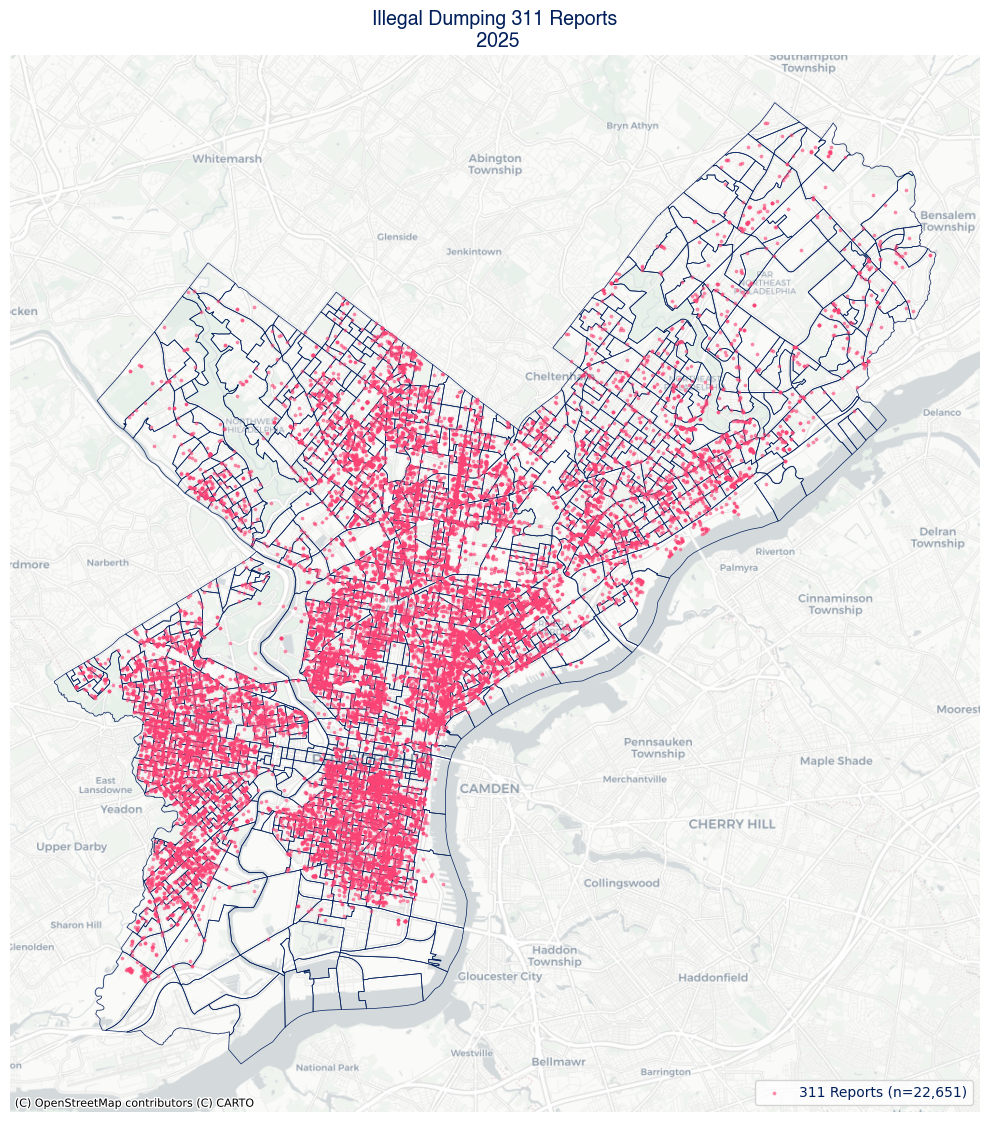

In [ ]:
# import os
# import geopandas as gpd
# import pandas as pd
# import matplotlib.pyplot as plt
# import contextily as ctx

# os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")

# # Load Philadelphia CBG boundary
# pa_2023 = gpd.read_file('data/tiger/tl_2023_42_bg/tl_2023_42_bg.shp')
# philly_cbg = pa_2023[pa_2023['COUNTYFP'] == '101'].to_crs(epsg=3857)

# # Load 2025 311 data and filter for Illegal Dumping, July–September
# litter_25 = gpd.read_file('data/311/2025/public_cases_fc.shp')
# litter_25 = litter_25[litter_25['service_na'] == "Illegal Dumping"].copy()
# litter_25["requested_"] = pd.to_datetime(litter_25["requested_"], errors="coerce")
# litter_25 = litter_25.dropna(subset=["requested_"])

# # Filter July–September 2025
# mask = (
#     (litter_25["requested_"].dt.year == 2025) &
#     (litter_25["requested_"].dt.month >= 1) &
#     (litter_25["requested_"].dt.month <= 12)
# )
# litter_q3 = litter_25[mask].to_crs(epsg=3857)

# # Plot
# fig, ax = plt.subplots(figsize=(10, 12))

# philly_cbg.plot(
#     ax=ax,
#     facecolor="none",
#     edgecolor="#011f5b",
#     linewidth=0.5,
#     zorder=2
# )

# litter_q3.plot(
#     ax=ax,
#     color="#fc4375",
#     markersize=3,
#     alpha=0.5,
#     zorder=3,
#     label=f"311 Reports (n={len(litter_q3):,})"
# )

# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

# ax.set_axis_off()
# ax.set_title("Illegal Dumping 311 Reports\n 2025", fontsize=14, fontweight="bold", color="#011f5b", family="Helvetica")

# legend = ax.legend(loc="lower right", fontsize=10)

# # text color
# for text in legend.get_texts():
#     text.set_color("#011f5b")

# plt.tight_layout()
# plt.savefig("/Users/yuxin/Desktop/illegal_dumping_311_2025.png", dpi=400,bbox_inches='tight',
#     pad_inches=0)
# plt.show()

/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_5430/4248782817.py:60: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = park.geometry.unary_union.centroid


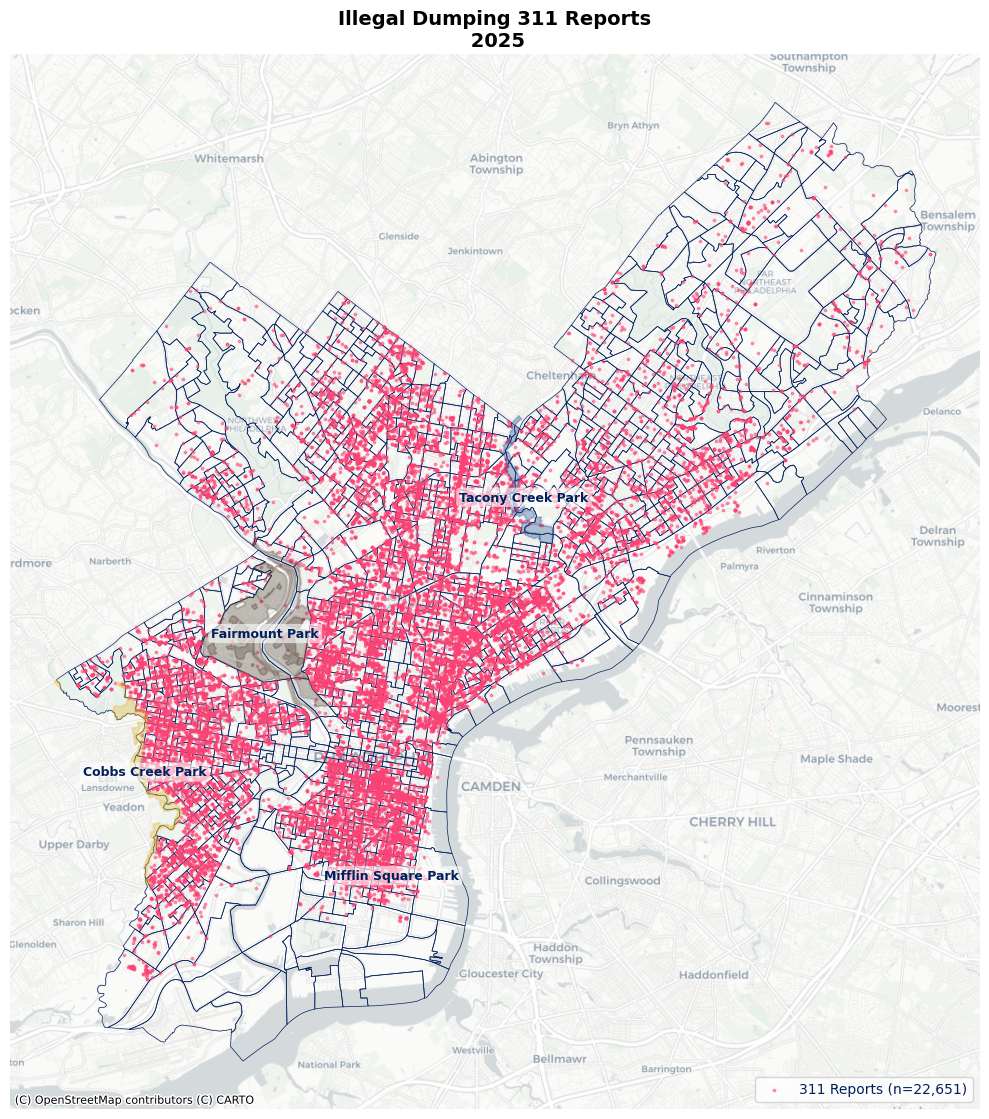

In [ ]:
# import os
# import geopandas as gpd
# import pandas as pd
# import matplotlib.pyplot as plt
# import contextily as ctx

# os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")

# # --- CBG boundary ---
# pa_2023 = gpd.read_file('data/tiger/tl_2023_42_bg/tl_2023_42_bg.shp')
# philly_cbg = pa_2023[pa_2023['COUNTYFP'] == '101'].to_crs(epsg=3857)

# # --- 311 data: July–September 2025 ---
# litter_25 = gpd.read_file('data/311/2025/public_cases_fc.shp')
# litter_25 = litter_25[litter_25['service_na'] == "Illegal Dumping"].copy()
# litter_25["requested_"] = pd.to_datetime(litter_25["requested_"], errors="coerce")
# litter_25 = litter_25.dropna(subset=["requested_"])
# mask = (
#     (litter_25["requested_"].dt.year == 2025) &
#     (litter_25["requested_"].dt.month >= 1) &
#     (litter_25["requested_"].dt.month <= 12)
# )
# litter_q3 = litter_25[mask].to_crs(epsg=3857)

# # --- Park boundaries ---
# ppr = gpd.read_file('parks/PPR/PPR_Properties.geojson')
# cobbscreek = ppr[ppr["OBJECTID"].isin([432])].to_crs(epsg=3857)
# mifflin    = ppr[ppr["OBJECTID"].isin([208])].to_crs(epsg=3857)
# tacony     = ppr[ppr["OBJECTID"].isin([10, 64])].to_crs(epsg=3857)
# fairmount  = ppr[ppr["OBJECTID"].isin([7, 9])].to_crs(epsg=3857)

# # --- Plot ---
# fig, ax = plt.subplots(figsize=(10, 12))

# philly_cbg.plot(ax=ax, facecolor="none", edgecolor="#011f5b", linewidth=0.5, zorder=2)

# litter_q3.plot(ax=ax, color="#fc4375", markersize=3, alpha=0.5, zorder=3,
#                label=f"311 Reports (n={len(litter_q3):,})")

# # Park outlines only (facecolor="none")
# cobbscreek.plot(ax=ax, facecolor="#e6b422", edgecolor="#e6b422", linewidth=1.2, zorder=4,alpha=0.3)
# mifflin.plot(   ax=ax, facecolor="#D0104C", edgecolor="#D0104C", linewidth=1.2, zorder=4,alpha=0.3)
# tacony.plot(    ax=ax, facecolor="#19448e", edgecolor="#19448e", linewidth=1.2, zorder=4,alpha=0.3)
# fairmount.plot( ax=ax, facecolor="#543f32", edgecolor="#543f32", linewidth=1.2, zorder=4,alpha=0.3)

# # --- Park name annotations ---
# annotation_kwargs = dict(
#     fontsize=9, fontweight="bold", color="#011f5b", zorder=6,
#     ha="center", va="center",
#     bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.6)
# )
# font_family = plt.rcParams["font.family"]

# for park, label in [
#     (cobbscreek, "Cobbs Creek Park"),
#     (mifflin,    "Mifflin Square Park"),
#     (tacony,     "Tacony Creek Park"),
#     (fairmount,  "Fairmount Park"),
# ]:
#     centroid = park.geometry.unary_union.centroid
#     ax.annotate(label, xy=(centroid.x, centroid.y), **annotation_kwargs,
#                 fontfamily=font_family)

# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

# ax.set_axis_off()
# ax.set_title("Illegal Dumping 311 Reports\n 2025", fontsize=14, fontweight="bold")

# legend = ax.legend(loc="lower right", fontsize=10)
# for text in legend.get_texts():
#     text.set_color("#011f5b")

# plt.tight_layout()
# plt.savefig("/Users/yuxin/Desktop/illegal_dumping_311_2025.png", dpi=400,
#             bbox_inches='tight', pad_inches=0)
# plt.show()

## Loading shapefiles

### Get University City's polygon

In [14]:
# ## downloaded from https://github.com/opendataphilly/open-geo-data/tree/master/philadelphia-neighborhoods
# philly_neighbor = gpd.read_file('data/philadelphia-neighborhoods.geojson')
# philly_neighbor = philly_neighbor.to_crs(26918)

# ## restrict to University City
# univ_city = philly_neighbor[philly_neighbor['MAPNAME'] == 'University City']

In [15]:
# ## set buffer square
# buffer_val = 300  # meters
# minx, miny, maxx, maxy = univ_city.total_bounds
# univ_square = geom.box(minx - buffer_val, miny - buffer_val,
#                               maxx + buffer_val, maxy + buffer_val)

# # Wrap into GeoDataFrame for plotting/export
# univ_square_gdf = gpd.GeoDataFrame(geometry=[univ_square], crs=univ_city.crs)

In [16]:
## export to geojson
# univ_square_gdf.to_file('output/univ_square_gdf.geojson', driver='GeoJSON')


In [17]:
# fig,ax = plt.subplots()
# univ_city.plot(ax=ax)
# univ_square_gdf.plot(ax= ax, edgecolor = "blue", color = "none")

In [18]:
# ## check if univ_city is all-covered by foot traffic data
# # load foor traffic data
# df_avg_geo = gpd.read_file('output/ft_avg_geo.geojson')

# ft_univ = df_avg_geo.sjoin(univ_square_gdf, predicate='intersects')

In [19]:
# ## plotting to check
# fig,ax = plt.subplots()
# univ_city.plot(ax=ax, edgecolor = "#011f5b", color = "none", linewidth=2, zorder=3)
# univ_square_gdf.plot(ax=ax, edgecolor = "blue", color = "none")
# ft_univ.plot(ax=ax, edgecolor = "red", color = "white", alpha = 0.5)

### Loading park boundaries

In [22]:
## load philly's city map for mapping
philly_border = gpd.read_file('data/City_Limits/City_Limits.shp')
philly_border = philly_border.to_crs(epsg=26918)

## load PPR data
ppr =gpd.read_file('parks/PPR/PPR_Properties.geojson')
ppr = ppr.to_crs(26918)

## get Cobbs Creek's map
cobbscreek = ppr[ppr["OBJECTID"].isin([432])]

## get Mifflin Square's map
mifflin = ppr[ppr["OBJECTID"].isin([208])]

## Tacony
tacony = ppr[ppr["OBJECTID"].isin([10, 64])]

## Fairmount
fairmount = ppr[ppr["OBJECTID"].isin([7, 9])]

In [21]:
# Loading park AOI
# file is download from Google My Map on Feb 3rd, 2026.
# polygons are drawn
park_aoi = gpd.read_file("parks/park_AOI_from_google.kml", driver='KML')
park_aoi = park_aoi.to_crs(epsg=26918)
display(park_aoi.head())  # Preview the first few rows of the file

# extract fairmount_aoi and cobbs_aoi separately by 'Name' column
fairmount_aoi = park_aoi[park_aoi['Name'] == 'fairmount_AOI'].copy()
cobbs_aoi = park_aoi[park_aoi['Name'] == 'cobbs_AOI'].copy()
cobbs_aoi_focus = park_aoi[park_aoi['Name'] == 'cobbs_AOI_focus'].copy()
taconyAOI = park_aoi[park_aoi['Name'] == 'taconyAOI'].copy()

,Name,Description,geometry
0,fairmount_AOI,,"POLYGON Z ((481383.057 4427165.027 0, 480031.7..."
1,cobbs_AOI,,"POLYGON Z ((480178.438 4420734.662 0, 480545.9..."
2,cobbs_AOI_focus,,"POLYGON Z ((479122.352 4421669.753 0, 480248.3..."
3,taconyAOI,,"POLYGON Z ((489302.808 4429653.688 0, 491720.0..."


#### Setting boxes around parks

In [22]:
# ## list of parks
# parks = {
#     'cobbscreek': cobbscreek,
#     'mifflin': mifflin,
#     'tacony': tacony,
#     'fairmount': fairmount
# }

# # set buffer value
# buffer = 300 # meters

# # collect results
# all_parks_gdf = gpd.GeoDataFrame() # for plotting
# all_boxes_gdf = gpd.GeoDataFrame() # for filtering

# # loop: get boxes around 
# for name, gdf in parks.items():
#     # skip empty GeoDataFrames
#     if gdf.empty:
#         continue
    
#     # store parks geometries
#     all_parks_gdf = pd.concat([all_parks_gdf, gdf], ignore_index=True)

#     # compute total bounds
#     minx, miny, maxx, maxy = gdf.total_bounds
#     minx -= buffer
#     maxx += buffer
#     miny -= buffer
#     maxy += buffer

#     # compute the side length of the square
#     side = max(maxx - minx, maxy - miny)
#     center_x = (minx + maxx) / 2
#     center_y = (miny + maxy) / 2

#     # create square box
#     square_minx = center_x - side / 2
#     square_maxx = center_x + side / 2
#     square_miny = center_y - side / 2
#     square_maxy = center_y + side / 2
#     square_geom = box(square_minx, square_miny, square_maxx, square_maxy)

#     # create GeoDataFrame for box
#     square_gdf = gpd.GeoDataFrame(
#         {'PARKNAME': [f"{name}_box"]},
#         geometry=[square_geom],
#         crs=gdf.crs
#     )

#     # add box to collection
#     all_boxes_gdf = pd.concat([all_boxes_gdf, square_gdf], ignore_index=True)

In [23]:
def create_parks_and_boxes(parks, max_area_sq_meters=2500000):
    """
    Create parks and bounding boxes GeoDataFrames from input parks dictionary.
    
    Parameters:
    -----------
    parks : dict
        Dictionary with keys as park names and values as GeoDataFrames.
        GeoDataFrames can have either:
        - Standard format: may have 'PARKNAME' column, or will use dict key
        - AOI format: must have 'Name' column (will be renamed to 'PARKNAME')
    
    max_area_sq_meters : float, default=2500000
        Maximum area for each bounding box in square meters.
        The function will calculate a dynamic buffer to maximize coverage
        while staying under this limit.
    
    Returns:
    --------
    all_parks_gdf : GeoDataFrame
        GeoDataFrame with columns ['PARKNAME', 'geometry'] containing all park geometries.
    
    all_boxes_gdf : GeoDataFrame
        GeoDataFrame with columns ['PARKNAME', 'geometry'] containing square (or original)
        bounding geometries for each park, with area <= max_area_sq_meters where applicable.
    """
    
    # Maximum side length for square box (area = side^2)
    max_side = np.sqrt(max_area_sq_meters)
    
    # Collect results
    all_parks_gdf = gpd.GeoDataFrame(columns=['PARKNAME', 'geometry'])
    all_boxes_gdf = gpd.GeoDataFrame(columns=['PARKNAME', 'geometry'])
    
    for name, gdf in parks.items():
        if gdf.empty:
            continue
        
        # Prepare park geometry for all_parks_gdf
        tmp_gdf = gdf.copy()
        
        # Handle CRS: ensure we're in a projected CRS (26918) for area calculations
        if tmp_gdf.crs is None:
            tmp_gdf = tmp_gdf.set_crs(4326).to_crs(26918)
        elif tmp_gdf.crs != 26918:
            tmp_gdf = tmp_gdf.to_crs(26918)
        
        # Handle PARKNAME column
        if 'PARKNAME' not in tmp_gdf.columns:
            if 'Name' in tmp_gdf.columns:
                tmp_gdf = tmp_gdf.rename(columns={'Name': 'PARKNAME'})
            else:
                tmp_gdf['PARKNAME'] = name
        
        # Add to all_parks_gdf
        tmp_gdf = tmp_gdf[['PARKNAME', 'geometry']]
        all_parks_gdf = pd.concat([all_parks_gdf, tmp_gdf], ignore_index=True)

        # Special case: for 'cobbs_aoi_focus', do NOT create an expanded box.
        # Instead, keep the original polygon as its "box" geometry and skip
        # the dynamic square buffer. Also, drop any Z coordinates so the
        # geometry is a 2D Polygon (not Polygon Z).
        if name == 'cobbs_aoi_focus':
            focus_box_gdf = tmp_gdf.copy()
            # Force geometries to 2D in case they are Polygon Z
            focus_box_gdf['geometry'] = focus_box_gdf['geometry'].apply(
                lambda geom: shapely.force_2d(geom) if geom is not None else geom
            )
            # Use the dict key as PARKNAME so you can select with 'cobbs_aoi_focus'
            focus_box_gdf['PARKNAME'] = name
            all_boxes_gdf = pd.concat(
                [all_boxes_gdf, focus_box_gdf[['PARKNAME', 'geometry']]],
                ignore_index=True,
            )
            continue
        
        # Calculate bounding box with dynamic buffer
        minx, miny, maxx, maxy = tmp_gdf.total_bounds
        width = maxx - minx
        height = maxy - miny
        
        # Minimum side needed to cover the polygon
        min_side = max(width, height)
        
        # Use maximum allowed side to maximize coverage
        # If min_side > max_side, we can't fully cover, so use max_side (maximum allowed)
        # Otherwise, use max_side to maximize coverage beyond the minimum needed
        side = max_side if min_side <= max_side else min(max_side, min_side)
        
        # Calculate center of original bounds
        center_x = (minx + maxx) / 2
        center_y = (miny + maxy) / 2
        
        # Create square box centered on the polygon
        square_minx = center_x - side / 2
        square_maxx = center_x + side / 2
        square_miny = center_y - side / 2
        square_maxy = center_y + side / 2
        square_geom = box(square_minx, square_miny, square_maxx, square_maxy)
        
        # Create GeoDataFrame for box
        square_gdf = gpd.GeoDataFrame(
            {'PARKNAME': [f"{name}_box"]},
            geometry=[square_geom],
            crs=tmp_gdf.crs
        )
        all_boxes_gdf = pd.concat([all_boxes_gdf, square_gdf[['PARKNAME', 'geometry']]], ignore_index=True)
    
    return all_parks_gdf, all_boxes_gdf


In [24]:

## Input parks dictionary
parks = {
    'cobbscreek': cobbscreek,
    'mifflin': mifflin,
    'tacony': tacony,
    'fairmount': fairmount,
    'fairmount_aoi': fairmount_aoi,
    'cobbs_aoi': cobbs_aoi,
    'taconyAOI': taconyAOI
    # 'cobbs_aoi_focus': cobbs_aoi_focus
}
## Create parks and boxes with dynamic buffer (max area = 2,500,000 sq meters)
# all_parks_gdf, all_boxes_gdf = create_parks_and_boxes(parks, max_area_sq_meters=3000000)
all_parks_gdf, all_boxes_gdf = create_parks_and_boxes(parks, max_area_sq_meters=1000000)

/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_22683/3073044478.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_22683/3073044478.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


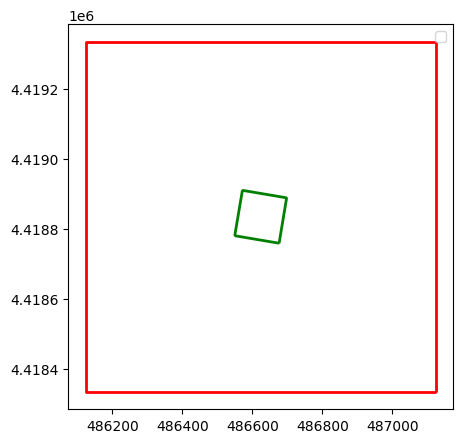

In [25]:
fig, ax = plt.subplots(figsize=(5, 5))

# Park polygon (PARKNAME is "mifflin" in all_parks_gdf)
all_parks_gdf[all_parks_gdf["PARKNAME"] == "mifflin"].plot(
    ax=ax,
    edgecolor="green",
    facecolor="none",
    linewidth=2,
    label="Mifflin park",
)

# Box polygon (PARKNAME is "mifflin_box" in all_boxes_gdf)
all_boxes_gdf[all_boxes_gdf["PARKNAME"] == "mifflin_box"].plot(
    ax=ax,
    edgecolor="red",
    facecolor="none",
    linewidth=2,
    label="Mifflin box",
)

ax.set_aspect("equal")
ax.legend()
plt.show()

In [26]:
# ## export geoJSON
# all_parks_gdf.to_file("output/all_parks_gdf.geojson", driver="GeoJSON")
# all_boxes_gdf.to_file("output/all_boxes_gdf.geojson", driver="GeoJSON")

## Loadding cbg-level cov dataset

In [27]:
## load covariates
cov_gdf = gpd.read_file('output/cov_cbg.geojson')
cov_gdf = cov_gdf.to_crs(epsg=26918)

### Filtering points in each park

In [28]:


# First join: illegal dumping within all_boxes_gdf
illegal_dumping_in_park = illegal_dumping.sjoin(all_boxes_gdf, predicate='within')
illegal_dumping_in_park = illegal_dumping_in_park.drop(columns=['index_right'])

# Second join: filter to only keep points that are also in cov_cbg
illegal_dumping_in_park = illegal_dumping_in_park.sjoin(
    cov_gdf, 
    predicate='within', 
    how='inner'  # Only keep points that match both conditions
)

# set park name
park_name = "mifflin_box"

park_points = illegal_dumping_in_park[illegal_dumping_in_park['PARKNAME'] == park_name]
park_points.shape

(2212, 66)

In [29]:
illegal_dumping_in_park['PARKNAME'].unique()

array(['mifflin_box', 'tacony_box', 'cobbs_aoi_box', 'fairmount_aoi_box',
       'taconyAOI_box', 'fairmount_box'], dtype=object)

In [ ]:
random_offsets = np.random.uniform(0, 24 * 60 * 60, size=len(park_points))
park_points['jittered_time'] = park_points['start_time'] + pd.to_timedelta(random_offsets, unit='s')

### Generating locs_s - using original timestamp - <span style = "color:#990000" >UPDATED</span>

In [31]:
# get coordinates from the geometry
coords = pd.DataFrame({
    'x': park_points.geometry.centroid.x,
    'y': park_points.geometry.centroid.y
})

# calculate time difference in days from the minimum date
offset_seasonal = 30 * 0
min_year        = pd.to_datetime(park_points['start_time'].min())
min_time        = pd.Timestamp(f"{min_year.year}-01-01")
time            = (park_points['start_time'] - min_time).dt.total_seconds() / (24 * 60 * 60)
seasonal        = (time + offset_seasonal) % 365
park_points['time_diff']     = time
park_points['seasonal_diff'] = seasonal

# Create locs_s DataFrame
locs_s = pd.DataFrame({
    'X': coords['x'].astype(float),
    'Y': coords['y'].astype(float),
    'T': time.astype(float),
    'A': seasonal.astype(float)
})


/Users/yuxin/miniconda3/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/yuxin/miniconda3/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [32]:
locs_s.shape

(2212, 4)

### Covariates subset by park box

In [33]:
# ## get the park box
# park_box = all_boxes_gdf[all_boxes_gdf['PARKNAME']=="tacony_box"]
# ## align crs: 26198
# park_box = park_box.to_crs(philly_2023.crs)
# ## filer cbgs that intersect with the park box
# cbgs_around_park = philly_2023[philly_2023.geometry.intersects(park_box.geometry.iloc[0])]

# ## filer cov_gdf that intersect with the park box
# cov_park = cov_gdf[cov_gdf.geometry.intersects(park_box.geometry.iloc[0])]

# ## filter land use data within the park box
# land_use_current = land_use_current.to_crs(park_box.crs)
# land_use_current_park = land_use_current[land_use_current.geometry.intersects(park_box.geometry.iloc[0])]

# ## import camera points
# camera_gdf = gpd.read_file('output/camera_gdf.geojson')
# ## filter camera points that intersect with the park box
# camera_gdf = camera_gdf[camera_gdf.geometry.intersects(park_box.geometry.iloc[0])]

In [34]:
# ## import missing cbg
# #missing_cbg = pd.read_csv('output/missing_cbg.csv')
# #geoids = missing_cbg['GEOID'].astype(str)

# cbgs_around_park['GEOID'] = cbgs_around_park['GEOID'].astype(str)

# fig, ax = plt.subplots(figsize=(5,5))
# #all_parks_gdf[all_parks_gdf['PARENT_NAME']=="Tacony Creek Park"].plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=2)
# park_box.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1.5)
# cbgs_around_park.plot(ax=ax,  edgecolor='gray', facecolor='none', linewidth=1)
# camera_gdf.plot(ax=ax, edgecolor='green', marker = "D", facecolor='none')
# land_use_current_park[land_use_current_park['type'] == 'Water'].plot(ax=ax, color='blue', alpha=0.9)
# cov_park.plot(ax=ax, alpha=0.5, column='Water',cmap='RdBu',legend=True)
# park_points.plot(ax=ax, color='red',marker='x', alpha=0.1)
# #cbgs_around_park[cbgs_around_park['GEOID'].isin(geoids)].plot(ax=ax, color='#DB4D6D', edgecolor='#333333', alpha = 0.8)
# plt.show()

### Including litter survey data

In [35]:
## import csv file 
litter_survey = pd.read_csv("data/CSVFiles/litter_surveys_raw_20250730.csv")
print(litter_survey.shape)
print(litter_survey.columns)

# ## make sure the survey_start is in datetime format
litter_survey['survey_start'] = pd.to_datetime(litter_survey['survey_start'])

# print("Check the time range of the survey:")
# print(f'The earliest date is {litter_survey["survey_start"].min()}')
# print(f'The latest date is {litter_survey["survey_start"].max()}')

# litter_survey.head()

(74147, 21)
Index(['ObjectID', 'GlobalID', 'survey_start', 'survey_end', 'department',
       'Address', 'location_id', 'Litter Rating', 'Litter Types',
       'Vacant Lots', 'Vacant Lots Count', 'Requires Immediate Action',
       'Requires Immediate Action Location Description', 'user', 'email',
       'CreationDate', 'Creator', 'EditDate', 'Editor', 'x', 'y'],
      dtype='object')


/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_22683/2291427997.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  litter_survey = pd.read_csv("data/CSVFiles/litter_surveys_raw_20250730.csv")


In [36]:
# First create geometry in WGS84
litter_gdf = gpd.GeoDataFrame(
    litter_survey,
    geometry=gpd.points_from_xy(litter_survey['x'], litter_survey['y']),
    crs="EPSG:4326"          # WGS84
)

# --- 2. Project to EPSG:26918 ---
litter_gdf_26918 = litter_gdf.to_crs(epsg=26918)

# Extract projected coordinates
litter_gdf_26918['X'] = litter_gdf_26918.geometry.x.astype(float)
litter_gdf_26918['Y'] = litter_gdf_26918.geometry.y.astype(float)

# --- 3. Convert rating 1–4 → 0–3 ---
litter_gdf_26918['score'] = (
    litter_gdf_26918['Litter Rating'].astype(float).astype(int) - 1
)

# --- 4. Compute T to match the logic used for locs_s ---

# You computed model baseline as:
#     min_year = min(start_time)
#     baseline = Jan 1 of that year

# We need to use the SAME baseline as the Hawkes data.
# Assuming your 311 dataframe is called park_points:

min_year = pd.to_datetime(park_points['start_time'].min())
baseline_time = pd.Timestamp(f"{min_year.year}-01-01")

# Days since baseline (same as your locs_s code)
litter_gdf_26918['T'] = (
    (litter_gdf_26918['survey_start'] - baseline_time)
    .dt.total_seconds() / (24 * 60 * 60)
)

# day in year
litter_gdf_26918['A'] = (litter_gdf_26918['T'] + offset_seasonal) % 365

# --- 5. FILTER LITTER POINTS TO THE MODEL'S SPATIAL DOMAIN ---
park_boundary = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name]

# Ensure boundary is in same CRS (should already be, but safe)
park_boundary = park_boundary.to_crs(epsg=26918)

# Spatial join: keep only litter points inside the park polygon
litter_within_park = gpd.sjoin(
    litter_gdf_26918,
    park_boundary,
    how="inner",
    predicate="within"
)

# --- 6. Final dataframe for the model ---
litter_df_for_model = litter_within_park[['X', 'Y', 'T', 'A', 'score']].copy()
litter_df_for_model = litter_df_for_model[(litter_df_for_model['T'] > 0) & (litter_df_for_model['T'] < np.max(locs_s['T']))]
litter_df_for_model.shape

(524, 5)

In [37]:
dumping_cleanup_gdf = gpd.read_file(
    "data/PPR_BaseFiles_IllegalDumpingModel.gdb",
    layer='PPR_Ops_Dumping_Cleanup_Complete'
)

# --- 2. Project to EPSG:26918 ---
dumping_cleanup_gdf_26918 = dumping_cleanup_gdf.to_crs(epsg=26918)

# --- 3. Compute T to match the logic used for locs_s ---

# You computed model baseline as:
#     min_year = min(start_time)
#     baseline = Jan 1 of that year

# We need to use the SAME baseline as the Hawkes data.
# Assuming your 311 dataframe is called park_points:

min_year = pd.to_datetime(park_points['start_time'].min())
baseline_time = pd.Timestamp(f"{min_year.year}-01-01 17:00:00", tz='UTC')

# Days since baseline (same as your locs_s code)
dumping_cleanup_gdf_26918['T'] = (
    (dumping_cleanup_gdf_26918['CLEANUP_DATE'] - baseline_time)
    .dt.total_seconds() / (24 * 60 * 60)
)

# day in year
dumping_cleanup_gdf_26918['A'] = (dumping_cleanup_gdf_26918['T'] + offset_seasonal) % 365

# --- 4. FILTER CLEANUP POINTS TO THE MODEL'S SPATIAL DOMAIN ---
park_boundary = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name]

# Ensure boundary is in same CRS (should already be, but safe)
park_boundary = park_boundary.to_crs(epsg=26918)

# Spatial join: keep only cleanup points inside the park polygon
dumping_cleanup_within_park = gpd.sjoin(
    dumping_cleanup_gdf_26918,
    park_boundary,
    how="inner",
    predicate="within"
)

# After the spatial join, strictly filter for points within the park polygon (in case of any spatial join artifacts)
# (not strictly necessary for 'within' join, but extra caution)
dumping_cleanup_within_park = dumping_cleanup_within_park[
    dumping_cleanup_within_park.geometry.within(park_boundary.iloc[0]['geometry'])
].copy()

# --- 5. Extract projected coordinates FROM FILTERED GEOMETRY ---
# IMPORTANT: Extract X, Y from the filtered geometry to ensure coordinates are within boundary
dumping_cleanup_within_park['X'] = dumping_cleanup_within_park.geometry.x.astype(float)
dumping_cleanup_within_park['Y'] = dumping_cleanup_within_park.geometry.y.astype(float)

# --- 6. Final dataframe for the model ---
dumping_cleanup_df_for_model = dumping_cleanup_within_park[['X', 'Y', 'T', 'A']].copy()
dumping_cleanup_df_for_model['log_cleanup_cost'] = np.log(dumping_cleanup_within_park['TOTAL_CLEANUP_COST'])
dumping_cleanup_df_for_model = dumping_cleanup_df_for_model[(dumping_cleanup_df_for_model['T'] > 0) & (dumping_cleanup_df_for_model['T'] < np.max(locs_s['T']))]
dumping_cleanup_df_for_model.shape

(31, 5)

In [38]:
locs_combined = pd.concat([locs_s, dumping_cleanup_df_for_model.drop(columns='log_cleanup_cost')], ignore_index=True)

## Model fitting

In [39]:
importlib.reload(bstpp.utils)
importlib.reload(bstpp.cox_hawkes_shared)
importlib.reload(bstpp.main)

<module 'bstpp.main' from '/Users/yuxin/BSTPP/bstpp/main.py'>

In [40]:
## Cox-Hawkes model

# a_0 = baseline log-intensity
# alpha = magnitute of excitation
# bate = temporal decay rate
# sigmax_2 = spatial decay scale
column_names = ['pop_density', 'med_inc_avg','lep_density','edu_hs_avg','ndvi_mean_4yr'
                ,'RLD', 'RMD','RHD','use_com', 'use_civ','I', 'T', 'GW',
                'vac_area','landcare_area',
                'alloc_avg_d_cnt','alloc_avg_s_cnt','unique_device_ratio_aw', 'reporting_rate',
                'betweenness_avg_w', 'pagerank_avg_w', 'betweenness_avg_d','pagerank_avg_d']

#model = bstpp.main.Hawkes_Model(
#    locs_s,     # spatiotemporal points
#    #univ_square_gdf,
#    all_boxes_gdf[all_boxes_gdf['PARKNAME']==park_name], # philly boundaries
#    total_days, # Time frame
#    True,       # use Cox as background
#    spatial_cov = cov_gdf,#spatial covariate matrix
#    cov_names = column_names,#columns to use from covariates
#    standardize_cov = True,
##    a_0      = dist.Normal(0,2),
##    alpha    = dist.Beta(2,2),
#    a_0=dist.Normal(0,.5),
#    alpha=dist.Beta(2,4),
#    #beta     = dist.HalfNormal(1.0),
#    beta     = dist.Exponential(1.0),
#    gamma    = dist.Exponential(1.0),
#    sigmax_2 = dist.HalfNormal(0.25),
#    offset_seasonal = offset_seasonal,
#    temporal_trig = bstpp.trigger.Temporal_Power_Law
#)

model = bstpp.cox_hawkes_shared.Cox_Hawkes_Shared(
    locs_s, #locs_s,
    all_boxes_gdf[all_boxes_gdf['PARKNAME']==park_name], # philly boundaries
    total_days,
    True,
    spatial_cov=cov_gdf, #cov_gdf_no_reporting_rate,
    cov_names=column_names,
    standardize_cov=True,
    # optional: override priors
    a_0=dist.Normal(0,.5),
    alpha=dist.Beta(2,4),
    temporal_trig = bstpp.trigger.Temporal_Power_Law
)
model.args['model'] = 'cox_hawkes'
model.args = bstpp.cox_hawkes_shared.attach_litter_survey_args(model, litter_df_for_model, 'score')
#model.args = bstpp.cox_hawkes_shared.attach_dumping_report_args(model, dumping_cleanup_df_for_model, 'log_cleanup_cost')

In [41]:
model.set_window(window = 100, spatial_window= 0.1)

[DEBUG] set_window called with:
  window type: <class 'float'> value: 100.0
  spatial_window type: <class 'float'> value: 0.1
[DEBUG] aligned_difference_pairs called with:
  t type: <class 'numpy.ndarray'> dtype: float64 shape: (2212,)
  x type: <class 'numpy.ndarray'> dtype: float64 shape: (2212,)
  y type: <class 'numpy.ndarray'> dtype: float64 shape: (2212,)
  window type: <class 'float'> value: 100.0
  spatial_window type: <class 'float'> value: 0.1
[set_window] Temporal window set to: 100.0
[set_window] Number of events: 2212
[set_window] Number of pairs: 134736
[set_window] Max t_diff in pairs: 49.42463850837139
[set_window] Min t_diff in pairs: 1.9025875186429175e-05
[set_window] All t_diff <= window: True
[set_window] All t_diff > 0: True
[set_window] Spatial window set to: 0.1
[set_window] Max spatial distance: 0.09999832510948181
[set_window] Min spatial distance: 0.0
[set_window] All spatial distances <= window: True


In [42]:
model.get_params().keys()

dict_keys(['alpha', 'beta', 'gamma', 'sigmax_2', 'z_spatial', 'z_temporal', 'z_seasonal', 'f_xy', 'f_t', 'f_a', 'w_month', 'a_0', 'w', 'gamma_l0', 'gamma_l1', 'cutpoints_unordered'])

100%|██████████| 20000/20000 [01:17<00:00, 257.63it/s, init loss: 84468.4219, avg. loss [19001-20000]: -42991.2891]


Number of posterior samples: 1000
Number of pairs: 134736
coords shape: (134736, 2)

SVI elapsed time: 86.96774864196777


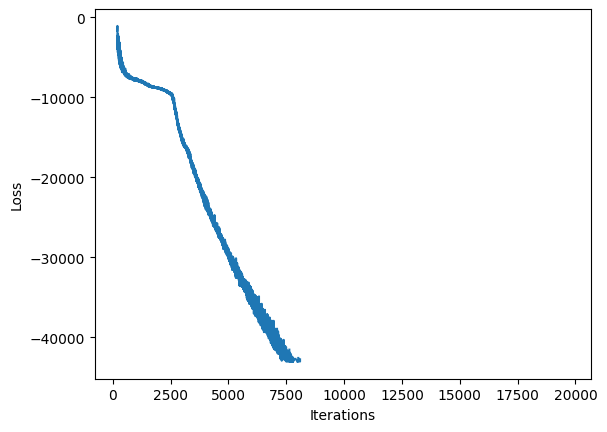

In [43]:
## less interations and bigger learning rate
model.run_svi(lr=0.01,num_steps=20000)
##model.run_svi(lr=0.001,num_steps=10000)
##model.run_svi(lr=0.03,num_steps=10000)

In [44]:
xy = model.args.get('xy_events', None)
print("xy_events raw type:", type(xy))
try:
    print("xy_events shape (if numpy/jnp):", getattr(xy, 'shape', None))
except Exception as e:
    print("Could not read shape:", e)

# If you have separate x/y
print("x_vals shape:", getattr(model.args.get('x_vals', None), 'shape', None))
print("y_vals shape:", getattr(model.args.get('y_vals', None), 'shape', None))

xy_events raw type: <class 'numpy.ndarray'>
xy_events shape (if numpy/jnp): (2, 2212)
x_vals shape: (134736,)
y_vals shape: (134736,)


## Results

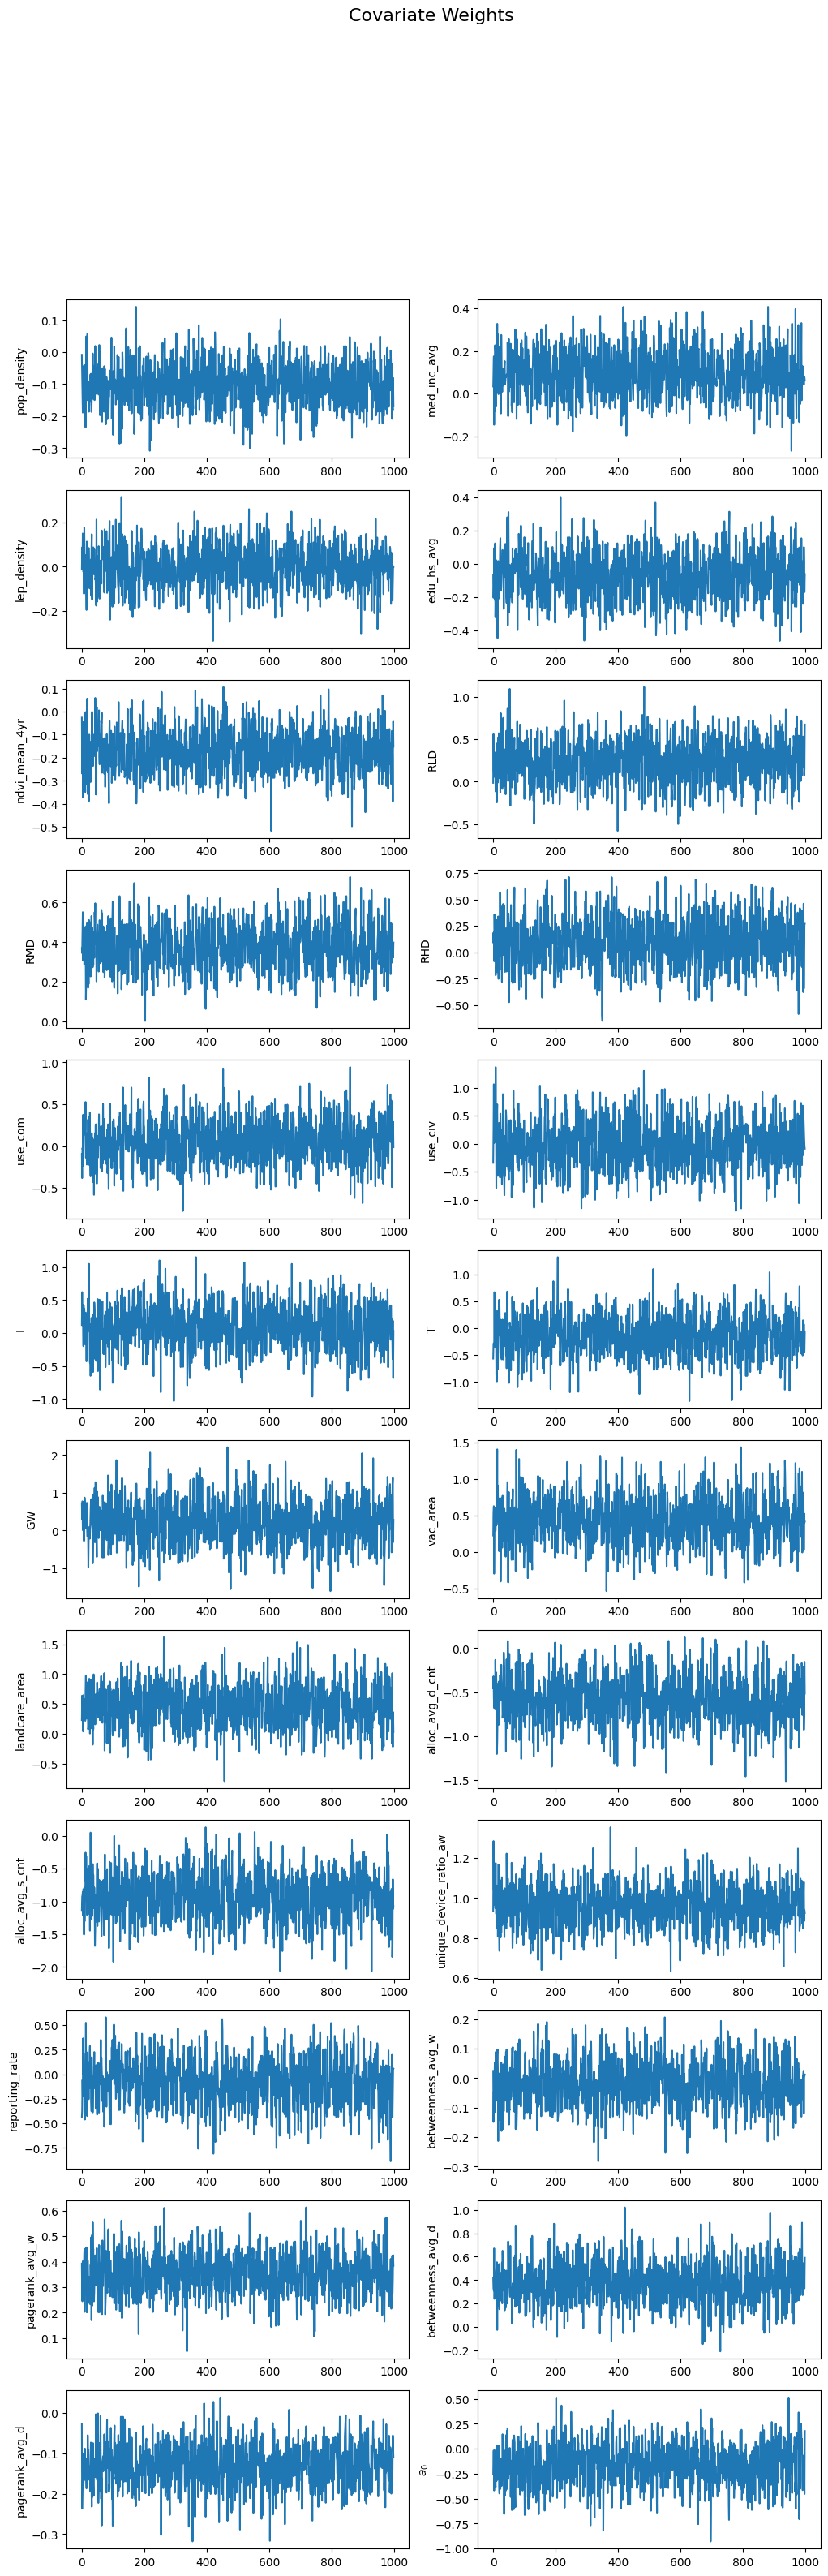

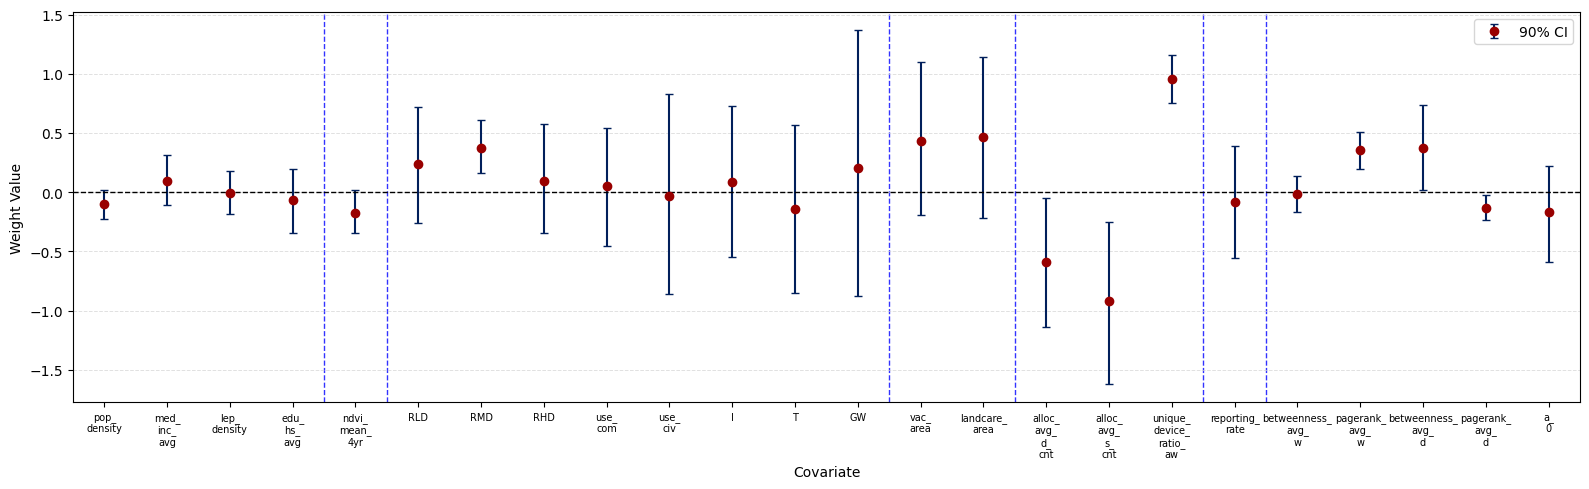

In [45]:

# Save the original plt.show function
original_show = plt.show

# Replace it with a no-op function
plt.show = lambda: None

# Call the function (it won't actually show)
model.cov_weight_post_summary(trace=True)

# Get the figure and save it
fig = plt.gcf()
fig.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_cov_coef.png", dpi=500, bbox_inches='tight')

# Restore the original plt.show
plt.show = original_show

# Optionally show it now if you want
# plt.show()


In [46]:
# importlib.reload(bstpp.cox_hawkes_latent)
# bstpp.cox_hawkes_latent.plot_report_cov_weight_post_summary(model,trace=False)

In [47]:
# model.samples['cutpoints_unordered']

- Higher values indicate better model fit to the data

In [48]:
# model.log_expected_likelihood(locs_s)

In [49]:
# model.expected_AIC()

**Model Evaluation**
- Constant Rate Baseline: 
    - Formula: rate = n_events / (area × T)
    - Log-likelihood: n_events × log(rate) - rate × area × T
    - AIC: -2 × log_likelihood + 2 × 1 (1 parameter = the rate)
    - Assumes constant intensity everywhere

- Spatial-Only Baseline:
    - If no covariates provided: same as constant rate (falls back to constant)

- BIC (Bayesian Information Criterion):
    - Formula: -2 × log_likelihood + k × log(n)

- DIC (Deviance Information Criterion)::
    - Bayesian alternative to AIC
    - Formula: D_mean + p_D where p_D is effective parameters
    - Accounts for posterior uncertainty
    - Note: baselines show NaN for DIC because they're not Bayesian models

In [50]:
from bstpp.model_evaluation import improvement_summary


# Compare with baselines - this shows if your model is actually good!
improvement_summary(
    model, 
    data=locs_s, 
    A=all_boxes_gdf[all_boxes_gdf['PARKNAME']==park_name], 
    T=total_days,
    spatial_cov=cov_gdf,
    cov_names=column_names
)

MODEL FIT EVALUATION SUMMARY

Fitted Model: Cox_Hawkes_Shared
  AIC: -88688.17
  BIC: -88209.23
  DIC: -88856.17
  Log Likelihood: 44428.09
  Parameters: 84

Best Baseline: Baseline: Constant Rate
  AIC: 64695.01
  BIC: 64700.71
  Log Likelihood: -32346.50

Improvement over Best Baseline:
  AIC Improvement: 153383.18 (Better)
  BIC Improvement: 152909.94 (Better)

✓ Significant improvement (AIC difference > 10)


Full Comparison Table:
                  Model  Log Likelihood           AIC           BIC           DIC  N Parameters         Type  AIC Improvement  BIC Improvement
      Cox_Hawkes_Shared    4.442809e+04 -8.868817e+04 -8.820923e+04 -88856.171875            84 Fitted Model     1.533832e+05     1.529099e+05
Baseline: Constant Rate   -3.234650e+04  6.469501e+04  6.470071e+04           NaN             1     Baseline     0.000000e+00     0.000000e+00
 Baseline: Spatial-Only   -1.668712e+06  3.337473e+06  3.337610e+06           NaN            24     Baseline    -3.272778e+06    -3

,Model,Log Likelihood,AIC,BIC,DIC,N Parameters,Type,AIC Improvement,BIC Improvement
0,Cox_Hawkes_Shared,4.442809e+04,-8.868817e+04,-8.820923e+04,-88856.171875,84,Fitted Model,1.533832e+05,1.529099e+05
1,Baseline: Constant Rate,-3.234650e+04,6.469501e+04,6.470071e+04,NaN,1,Baseline,0.000000e+00,0.000000e+00
2,Baseline: Spatial-Only,-1.668712e+06,3.337473e+06,3.337610e+06,NaN,24,Baseline,-3.272778e+06,-3.272909e+06
3,Baseline: Temporal-Only,-3.234650e+04,6.469501e+04,6.470071e+04,NaN,1,Baseline,0.000000e+00,0.000000e+00


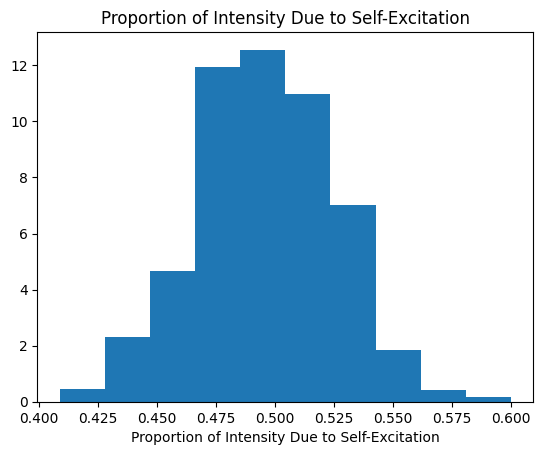

In [51]:
# Save the original plt.show function
original_show = plt.show

# Replace it with a no-op function
plt.show = lambda: None

# Call the function (it won't actually show)
model.plot_prop_excitation()

# Get the figure and save it
fig = plt.gcf()
fig.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_prop_excitation.png", dpi=500, bbox_inches='tight')

# Restore the original plt.show
plt.show = original_show

# Optionally show it now if you want
# plt.show()

In [52]:
par_names = model.args['t_trig'].get_par_names()
print(par_names)

['beta', 'gamma']


,Post Mean,Post Std,P(w>0),[0.025,0.975]
alpha,9.962583e-01,1.880646e-03,1.0,9.912671e-01,9.986607e-01
beta,1.293965e-01,7.487842e-03,1.0,1.146153e-01,1.447420e-01
gamma,9.939192e-02,1.281470e-02,1.0,7.534822e-02,1.261686e-01
sigmax_2,6.242656e-20,1.142434e-20,1.0,4.252282e-20,8.765569e-20


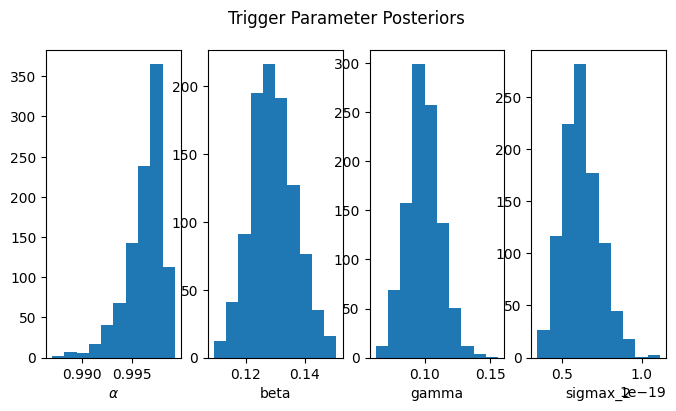

In [53]:
model.plot_trigger_posterior(trace=False)

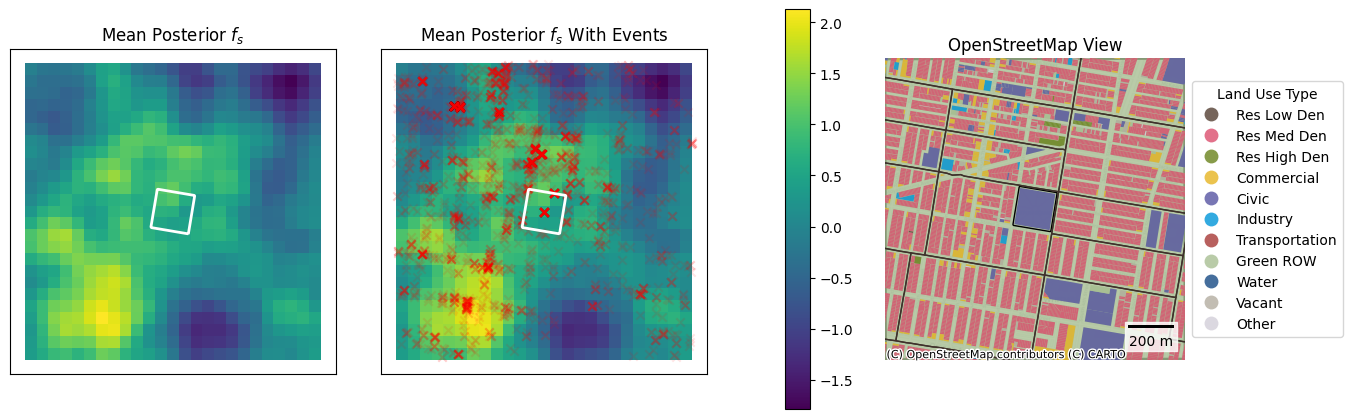

In [54]:
## Spatial trigger ------------------------------------------------------
# Step 1: Draw the original plot
model.plot_spatial(include_cov=False)

# Step 2: Grab the existing figure and axes
fig = plt.gcf()
axs = fig.get_axes()  # Usually [ax0, ax1, colorbar_ax]

# Match limits from left subplot
xlim = axs[0].get_xlim()
ylim = axs[0].get_ylim()

#philly_border.plot(ax=axs[0], edgecolor='red', facecolor='none', linewidth=2)
all_parks_gdf.plot(ax=axs[0], edgecolor='white', facecolor='none', linewidth=2)
philly_border.plot(ax=axs[0], edgecolor='darkgray', facecolor='none', linewidth=2)

axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].get_xaxis().set_visible(False)
axs[0].get_yaxis().set_visible(False)

# Add overlays
#all_boxes_gdf.plot(ax=axs[1], edgecolor='blue', facecolor='none', linewidth=2)
philly_border.plot(ax=axs[1], edgecolor='darkgray', facecolor='none', linewidth=2)
all_parks_gdf.plot(ax=axs[1], edgecolor='white', facecolor='none', linewidth=2)


# Set the same limits on the right subplot
axs[1].set_xlim(xlim)
axs[1].set_ylim(ylim)
axs[1].get_xaxis().set_visible(False)
axs[1].get_yaxis().set_visible(False)

# Step 3: Add a new axis to the right
osm_ax = fig.add_axes([1, 0.1, 0.3, 0.8])  # [left, bottom, width, height]

# Step 4: Draw the OpenStreetMap on the new axis
osm_box = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name].to_crs(epsg=3857)
philly_2023_3857 = philly_2023.to_crs(epsg=3857)
all_parks_3857 = all_parks_gdf.to_crs(epsg=3857)
land_use_current = land_use_current.to_crs(epsg=3857)
land_care_21_25 = land_care_21_25.to_crs(epsg=3857)
vacant_block = vacant_block.to_crs(epsg = 3857)

# plot cbg and park boundary
philly_2023_3857.plot(ax=osm_ax, edgecolor='#3f312b', facecolor='none', linewidth=1, zorder=3)
all_parks_3857.plot(ax=osm_ax, color='none', edgecolor='black', linewidth=1, zorder=2)
osm_box.plot(ax=osm_ax, edgecolor='black', facecolor='none', linewidth=2, zorder=1)
#land_care_21_25.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='#00ffff', alpha=0.7,linewidth=1,zorder=4)
#vacant_block.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='gray', alpha=0.7,linewidth=1, zorder=4)

## plot land use type
land_use_current['type'] = land_use_current['type'].astype('category')
#cmap = 'tab20b' # set qualitatitive color map
cmap = ListedColormap(use_color)

land_use_current[land_use_current['year'] == 2023].plot(
    ax=osm_ax,
    column='type',
    cmap=cmap,
    alpha=0.8,
    legend=True,
    legend_kwds={
        'loc': 'center left',
        'bbox_to_anchor': (1, 0.5),
        'title': 'Land Use Type'
    }
)

# Zoom to Cobbs Creek Park
xlim = osm_box.total_bounds[[0, 2]]
ylim = osm_box.total_bounds[[1, 3]]
osm_ax.set_xlim(xlim)
osm_ax.set_ylim(ylim)

ctx.add_basemap(osm_ax, source=ctx.providers.CartoDB.Positron)
#ctx.add_basemap(osm_ax)


# Add the scale bar in kilometers
scalebar = ScaleBar(
    dx=1,  # 1 pixel = 1 meter (Web Mercator)
    units='m',  # use kilometers
    dimension='si-length',
    length_fraction=0.25,
    location='lower right',
    scale_loc='bottom',
    box_color='white',
    box_alpha=0.8,
    border_pad=0.6,
    color='black',
    font_properties={'size': 10}
)
osm_ax.add_artist(scalebar)

# Optional: Clean up
osm_ax.set_title("OpenStreetMap View")
osm_ax.set_axis_off()

#plt.savefig('output/spatial_trigger_mifflin_zoning_full.png', dpi=500, bbox_inches='tight')
plt.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_spatial_trigger.png", dpi=500, bbox_inches='tight')


Grid size: 25x25


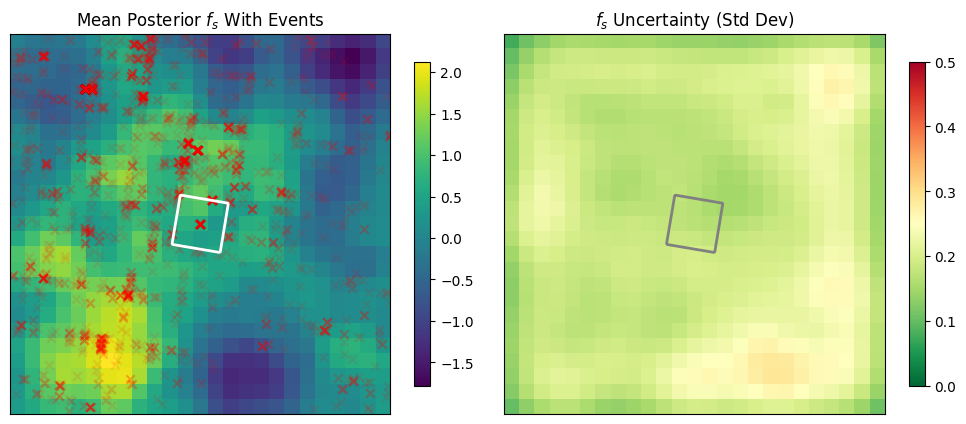

Mean f_xy range: -1.785 to 2.128
Std f_xy range: 0.078 to 0.288


In [55]:
## Uncertainty map ------------------------------------------------------
# Get uncertainty measures
f_xy_samples = model.samples["f_xy"]
f_xy_mean = np.mean(f_xy_samples, axis=0)
f_xy_std = np.std(f_xy_samples, axis=0) # Standard deviation across samples

# Get boundary from model.A geometry
bounds = model.A[['geometry']].total_bounds  # [minx, miny, maxx, maxy]
minx, miny, maxx, maxy = bounds

# Since spatial_grid contains indices, we need to create coordinates
# For a 625-cell grid, this is likely a 25x25 grid (25² = 625)
grid_size = int(np.sqrt(625))  # Should be 25
print(f"Grid size: {grid_size}x{grid_size}")

# Create coordinate arrays based on actual geometry bounds
x_indices = np.linspace(minx, maxx, grid_size)
y_indices = np.linspace(miny, maxy, grid_size)
X, Y = np.meshgrid(x_indices, y_indices)

# Reshape your data to match the grid
f_xy_mean_grid = f_xy_mean.reshape(grid_size, grid_size)
f_xy_std_grid = f_xy_std.reshape(grid_size, grid_size)

# Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Mean surface
im1 = ax1.imshow(f_xy_mean_grid, origin='lower', cmap='viridis', extent=[minx, maxx, miny, maxy])
model.points.plot(ax=ax1,color='red',marker='x',alpha=0.1)
all_parks_gdf.plot(ax=ax1, edgecolor='white', facecolor='none', linewidth=2)

ax1.set_title('Mean Posterior $f_s$ With Events')
ax1.set_xlim(minx, maxx)  # Set x limits to bounds
ax1.set_ylim(miny, maxy)  # Set y limits to bounds

ax1.get_xaxis().set_visible(False)
ax1.get_yaxis().set_visible(False)

plt.colorbar(im1, ax=ax1, shrink=0.7)

# Uncertainty surface
im2 = ax2.imshow(f_xy_std_grid, origin='lower', cmap='RdYlGn_r', extent=[minx, maxx, miny, maxy], vmin=0, vmax=0.5)
all_parks_gdf.plot(ax=ax2, edgecolor='gray', facecolor='none', linewidth=2)

ax2.set_title('$f_s$ Uncertainty (Std Dev)')
ax2.set_xlim(minx, maxx)  # Set x limits to bounds
ax2.set_ylim(miny, maxy)  # Set y limits to bounds

ax2.get_xaxis().set_visible(False)
ax2.get_yaxis().set_visible(False)

plt.colorbar(im2, ax=ax2, shrink=0.7)

plt.tight_layout()
# plt.savefig('output/uncertainty_mifflin.png', dpi=500, bbox_inches='tight')
plt.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_uncertainty.png", dpi=500, bbox_inches='tight')

plt.show()

# Print some summary statistics
print(f"Mean f_xy range: {f_xy_mean.min():.3f} to {f_xy_mean.max():.3f}")
print(f"Std f_xy range: {f_xy_std.min():.3f} to {f_xy_std.max():.3f}")

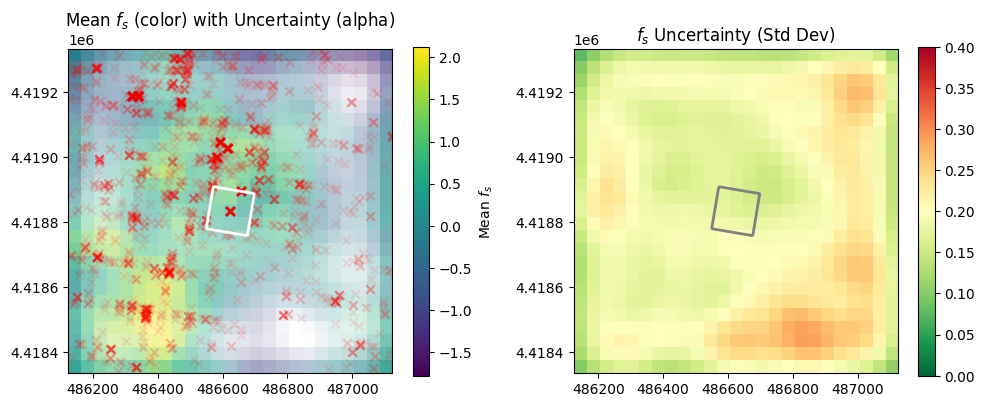

Mean f_xy range: -1.785 to 2.128
Std f_xy range: 0.078 to 0.288


In [56]:
## Uncertainty map with mean-colored, std-weighted alpha on ax1

# Get uncertainty measures
f_xy_samples = model.samples["f_xy"]
f_xy_mean = np.mean(f_xy_samples, axis=0)
f_xy_std = np.std(f_xy_samples, axis=0)  # Standard deviation across samples

# Get boundary from model.A geometry
bounds = model.A[["geometry"]].total_bounds  # [minx, miny, maxx, maxy]
minx, miny, maxx, maxy = bounds

# For a 625-cell grid, this is a 25x25 grid (25² = 625)
grid_size = int(np.sqrt(625))  # 25

# Coordinate arrays based on actual geometry bounds
x_indices = np.linspace(minx, maxx, grid_size)
y_indices = np.linspace(miny, maxy, grid_size)
X, Y = np.meshgrid(x_indices, y_indices)

# Reshape data to match the grid
f_xy_mean_grid = f_xy_mean.reshape(grid_size, grid_size)
f_xy_std_grid = f_xy_std.reshape(grid_size, grid_size)

# Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# --- ax1: mean as color, std as alpha ---
from matplotlib import colors as mcolors

# Normalize mean for colormap
cmap = plt.get_cmap("viridis")
norm_mean = mcolors.Normalize(vmin=f_xy_mean.min(), vmax=f_xy_mean.max())
rgba = cmap(norm_mean(f_xy_mean_grid))  # shape (25, 25, 4)

# Normalize std to [0, 1] and invert so higher uncertainty → more transparent
std_min, std_max = f_xy_std_grid.min(), f_xy_std_grid.max()
std_norm = (f_xy_std_grid - std_min) / (std_max - std_min + 1e-9)
alpha_grid = 1.0 - std_norm  # high std → low alpha

# Apply alpha to RGBA array
rgba[..., -1] = alpha_grid

# Show RGBA image
im1 = ax1.imshow(rgba, origin="lower", extent=[minx, maxx, miny, maxy])
model.points.plot(ax=ax1, color="red", marker="x", alpha=0.1)
all_parks_gdf.plot(ax=ax1, edgecolor="white", facecolor="none", linewidth=2)

ax1.set_title("Mean $f_s$ (color) with Uncertainty (alpha)")
ax1.set_xlim(minx, maxx)
ax1.set_ylim(miny, maxy)

# Add colorbar for the mean values (use the same colormap and norm)
cb1 = plt.colorbar(
    mappable=plt.cm.ScalarMappable(norm=norm_mean, cmap=cmap),
    ax=ax1,
    shrink=0.7
)
cb1.set_label("Mean $f_s$")

# --- ax2: keep the same std-dev map as before ---
im2 = ax2.imshow(
    f_xy_std_grid,
    origin="lower",
    cmap="RdYlGn_r",
    extent=[minx, maxx, miny, maxy],
    vmin=0,
    vmax=0.4,
)
all_parks_gdf.plot(ax=ax2, edgecolor="gray", facecolor="none", linewidth=2)

ax2.set_title("$f_s$ Uncertainty (Std Dev)")
ax2.set_xlim(minx, maxx)
ax2.set_ylim(miny, maxy)
plt.colorbar(im2, ax=ax2, shrink=0.7)

plt.tight_layout()
plt.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_uncertainty_opacity.png", dpi=500, bbox_inches='tight')

plt.show()

# Print some summary statistics
print(f"Mean f_xy range: {f_xy_mean.min():.3f} to {f_xy_mean.max():.3f}")
print(f"Std f_xy range: {f_xy_std.min():.3f} to {f_xy_std.max():.3f}")


In [57]:
# model.samples.keys()

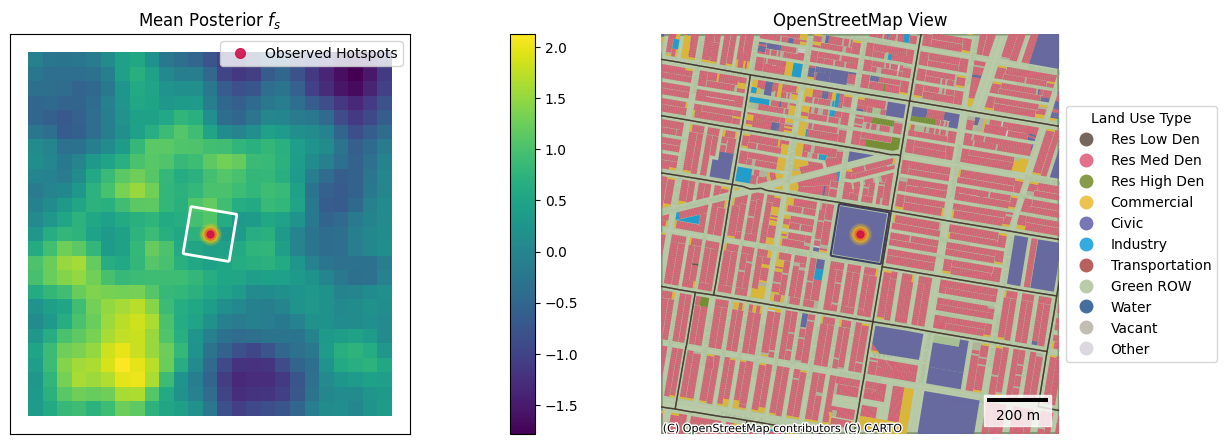

In [58]:
model.plot_spatial(include_cov=False)

# Get the current figure and axes ---------------------------------
fig = plt.gcf()
axes = fig.get_axes()

# Remove the right subplot (second axis)
fig.delaxes(axes[1])

# Match limits from left subplot
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

# Optionally adjust the remaining plot to use full width
axes[0].set_position([0.1, 0.1, 1, 0.8])

all_parks_gdf.plot(ax=axes[0], edgecolor='white', facecolor='none', linewidth=2)
philly_border.plot(ax=axes[0], edgecolor='darkgray', facecolor='none', linewidth=2)

# plot park hot spots
# Filter geodataframe to only points within bounds
filtered_gdf = dumping_hotspot_gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]

# Extract x, y coordinates
x = filtered_gdf.geometry.x
y = filtered_gdf.geometry.y

# Plot halo
axes[0].plot(x, y, 'o', color='#FFC408',markersize=17, markeredgewidth=0,alpha=0.1)
axes[0].plot(x, y, 'o', color='#FFC408',markersize=15, markeredgewidth=0,alpha=0.3)
axes[0].plot(x, y, 'o',  color='#FFC408', markersize=12, markeredgewidth=0,alpha=0.5)
axes[0].plot(x, y, 'o', color='#F49719',markersize=9, markeredgewidth=0,alpha=0.7)

# Plot points
axes[0].plot(x, y, 'o', color='#E86A2A',markersize=8,alpha=0.7)
axes[0].plot(x, y, 'o', color='#D0104C',markersize=5,alpha=0.9)
             

axes[0].set_xlim(xlim)
axes[0].set_ylim(ylim)

legend_handle = Line2D(
    [0], [0],
    marker='o',
    linestyle='None', 
    color='#D0104C',
    markerfacecolor='#D0104C',
    markersize=7,
    alpha=0.9,
    label='Observed Hotspots'
)

axes[0].legend(
    handles=[legend_handle],
    loc='upper right'
)

axes[0].set_xlim(xlim)
axes[0].set_ylim(ylim)
axes[0].get_xaxis().set_visible(False)
axes[0].get_yaxis().set_visible(False)

# Step 3: Add a new axis to the right ---------------------------------
osm_ax = fig.add_axes([1, 0.1, 0.5, 0.8])  # [left, bottom, width, height]

# Step 4: Draw the OpenStreetMap on the new axis
osm_box = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name].to_crs(epsg=3857)
philly_2023_3857 = philly_2023.to_crs(epsg=3857)
all_parks_3857 = all_parks_gdf.to_crs(epsg=3857)
land_use_current = land_use_current.to_crs(epsg=3857)



# plot cbg and park boundary
philly_2023_3857.plot(ax=osm_ax, edgecolor='#3f312b', facecolor='none', linewidth=1, zorder=3, alpha = 0.7)
all_parks_3857.plot(ax=osm_ax, color='none', edgecolor='#211E55', linewidth=1.5, zorder=2, alpha = 0.8)
osm_box.plot(ax=osm_ax, edgecolor='black', facecolor='none', linewidth=2, zorder=1)


## plot land use type
land_use_current['type'] = land_use_current['type'].astype('category')
#cmap = 'tab20b' # set qualitatitive color map
cmap = ListedColormap(use_color)

land_use_current[land_use_current['year'] == 2023].plot(
    ax=osm_ax,
    column='type',
    cmap=cmap,
    alpha=0.8,
    legend=True,
    legend_kwds={
        'loc': 'center left',
        'bbox_to_anchor': (1, 0.5),
        'title': 'Land Use Type'
    }
)

# plot park hot spots
# Filter geodataframe to only points within bounds
filtered_gdf = dumping_hotspot_gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
filtered_gdf_3857 = filtered_gdf.to_crs(epsg=3857)

# Extract x, y coordinates
x = filtered_gdf_3857.geometry.x
y = filtered_gdf_3857.geometry.y

# Plot halo
osm_ax.plot(x, y, 'o', color='#FFC408',markersize=17, markeredgewidth=0,alpha=0.1)
osm_ax.plot(x, y, 'o', color='#FFC408',markersize=15, markeredgewidth=0,alpha=0.3)
osm_ax.plot(x, y, 'o',  color='#FFC408', markersize=12, markeredgewidth=0,alpha=0.5)
osm_ax.plot(x, y, 'o', color='#F49719',markersize=9, markeredgewidth=0,alpha=0.7)

# Plot points
osm_ax.plot(x, y, 'o', color='#E86A2A',markersize=8,alpha=0.7)
osm_ax.plot(x, y, 'o', color='#D0104C',markersize=5,alpha=0.9)

# Zoom to Cobbs Creek Park
xlim = osm_box.total_bounds[[0, 2]]
ylim = osm_box.total_bounds[[1, 3]]
osm_ax.set_xlim(xlim)
osm_ax.set_ylim(ylim)

ctx.add_basemap(osm_ax, source=ctx.providers.CartoDB.Positron)
#ctx.add_basemap(osm_ax)


# Add the scale bar in kilometers
scalebar = ScaleBar(
    dx=1,  # 1 pixel = 1 meter (Web Mercator)
    units='m',  # use kilometers
    dimension='si-length',
    length_fraction=0.25,
    location='lower right',
    scale_loc='bottom',
    box_color='white',
    box_alpha=0.8,
    border_pad=0.6,
    color='black',
    font_properties={'size': 10}
)
osm_ax.add_artist(scalebar)

# Optional: Clean up
osm_ax.set_title("OpenStreetMap View")
osm_ax.set_axis_off()

#plt.savefig('output/ppr_hotspots_mifflin.png', dpi=500, bbox_inches='tight')
plt.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_ppr_hotspots.png", dpi=500, bbox_inches='tight')


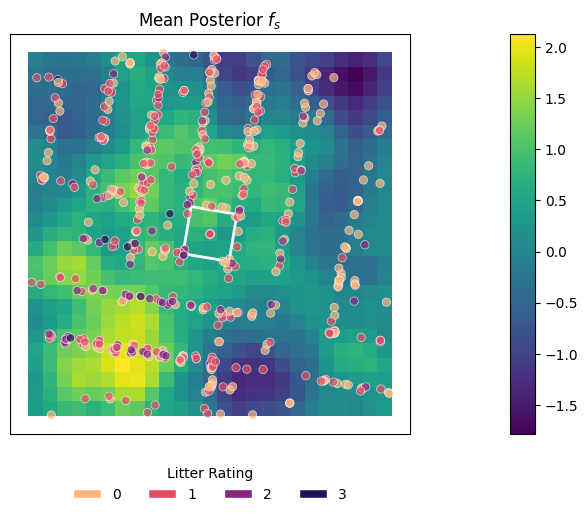

In [59]:
## plot litter rating with bg -------------------------------------------
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

model.plot_spatial(include_cov=False)

fig = plt.gcf()
axes = fig.get_axes()

# Remove the right subplot (second axis)
fig.delaxes(axes[1])

# Match limits from left subplot
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

# Optionally adjust the remaining plot to use full width
axes[0].set_position([0.1, 0.1, 1, 0.8])

all_parks_gdf.plot(ax=axes[0], edgecolor='white', facecolor='none', linewidth=2)
philly_border.plot(ax=axes[0], edgecolor='darkgray', facecolor='none', linewidth=2)

# Get the same 4 colors from viridis (0.15 to 0.85 range)
viridis_colors = plt.cm.viridis(np.linspace(0.15, 0.85, 4))
magma_colors = plt.cm.magma_r(np.linspace(0.15, 0.85, 4))

# Create a discrete colormap from these colors
cmap = mcolors.ListedColormap(magma_colors)

# Plot with white outline, but remap 'Litter Rating' to 0-3 scale for plotting
litter_within_park.plot(
    ax=axes[0],
    column=litter_within_park["Litter Rating"] - 1,  # Remap 1-4 --> 0-3
    cmap=cmap,
    edgecolor='white',
    linewidth=0.5,
    alpha=0.7,
    legend=False
)

# Create custom legend patches for 0-3 scale
legend_labels = [0, 1, 2, 3]
legend_patches = [Patch(facecolor=magma_colors[i], edgecolor='white', 
                        label=f'{legend_labels[i]}') 
                  for i in range(4)]

# Add legend at bottom
axes[0].legend(handles=legend_patches, 
               loc='upper center',
               bbox_to_anchor=(0.5, -0.05),
               ncol=4,
               frameon=False,
               title='Litter Rating')


axes[0].set_xlim(xlim)
axes[0].set_ylim(ylim)
axes[0].get_xaxis().set_visible(False)
axes[0].get_yaxis().set_visible(False)


plt.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_litter_rating_points.png", dpi=500, bbox_inches='tight')
plt.show()


In [60]:
# Helper functions for spatial plotting
def plot_hotspots_with_halo(ax, hotspot_gdf, xlim, ylim, crs_26918=True):
    """Plot hotspots with halo effect on given axis."""
    # Filter geodataframe to only points within bounds
    if crs_26918:
        filtered_gdf = hotspot_gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
    else:
        # For OSM axis, already in 3857
        filtered_gdf = hotspot_gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
    
    # Extract x, y coordinates
    x = filtered_gdf.geometry.x
    y = filtered_gdf.geometry.y
    
    # Plot halo layers
    ax.plot(x, y, 'o', color='#FFC408', markersize=17, markeredgewidth=0, alpha=0.1)
    ax.plot(x, y, 'o', color='#FFC408', markersize=15, markeredgewidth=0, alpha=0.3)
    ax.plot(x, y, 'o', color='#FFC408', markersize=12, markeredgewidth=0, alpha=0.5)
    ax.plot(x, y, 'o', color='#F49719', markersize=9, markeredgewidth=0, alpha=0.7)
    
    # Plot main points
    ax.plot(x, y, 'o', color='#E86A2A', markersize=8, alpha=0.7)
    
    # Add final layer with white border
    if crs_26918:
        ax.plot(x, y, 'o', color='#D0104C', markersize=5, alpha=0.9,
                markeredgecolor='white', markeredgewidth=0.7)
    else:
        ax.plot(x, y, 'o', color='#D0104C', markersize=5, alpha=0.9)


def get_color_from_group_name(group_name):
    """Map group name to matplotlib color.
    
    The group_name comes from JSON filenames like 'JSON RED.json' which 
    are converted to keys like 'json_red' in focus_group_gdfs.
    """
    # Convert to lowercase and strip whitespace first
    group_name = str(group_name).lower().strip()
    # Remove 'json_' prefix if present
    color = group_name.replace('json_', '').strip()
    
    valid_colors = {'red', 'blue', 'yellow', 'green', 'white', 'gray', 
                   'orange', 'purple', 'black', 'brown'}
    if color == "clear" or color not in valid_colors:
        return "gray"
    elif color == "white":
        return "#e7e6e6"  # use light gray for visibility
    else:
        return color


def get_label_from_color(color):
    """Map color to label for legend."""
    color = color.replace('json_', '').lower()
    color_label_map = {
        'blue': 'Household Waste/Cleanouts',
        'green': 'Yard & Landscaping Waste',
        'white': 'Tires & Auto Parts',
        'clear': 'Other',
        'yellow': 'Large Items',
        'red': 'Construction & Demolition Debris'
    }
    return color_label_map.get(color, 'Other')


def plot_focus_group_points(ax, focus_group_gdfs, xlim, ylim, 
                            markersize=9, crs_26918=True):
    """Plot focus group points on given axis."""
    import matplotlib.colors as mcolors
    
    for group_name, gdf in focus_group_gdfs.items():
        color_mpl = get_color_from_group_name(group_name)
        # Convert color to hex
        if color_mpl.startswith('#'):
            color_hex = color_mpl
        else:
            color_hex = mcolors.to_hex(color_mpl)
        
        # Debug: print color for red group
        if 'red' in group_name.lower():
            print(f"DEBUG: {group_name} -> color_mpl: {color_mpl} -> color_hex: {color_hex}")
        
        if crs_26918:
            # Filter for spatial axis (26918)
            filtered = gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
            if not filtered.empty:
                ax.scatter(filtered.geometry.x, filtered.geometry.y,
                          facecolors=color_hex, s=markersize**2, edgecolors='white',
                          linewidths=1, label=group_name, zorder=5)
        else:
            # For OSM axis (3857)
            if not gdf.empty:
                if gdf.crs != 'epsg:3857':
                    gdf_3857 = gdf.to_crs(epsg=3857)
                else:
                    gdf_3857 = gdf
                filtered_3857 = gdf_3857.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
                if not filtered_3857.empty:
                    ax.scatter(filtered_3857.geometry.x, filtered_3857.geometry.y,
                              facecolors=color_hex, s=markersize**2, edgecolors='white',
                              linewidths=1, label=group_name, zorder=5)


def transform_to_3857(*gdfs):
    """Transform multiple GeoDataFrames to EPSG:3857."""
    return [gdf.to_crs(epsg=3857) for gdf in gdfs]


def plot_boundaries(ax, philly_2023_3857, all_parks_3857, osm_box):
    """Plot boundary layers on OSM axis."""
    philly_2023_3857.plot(ax=ax, edgecolor='#3f312b', facecolor='none',
                          linewidth=1, zorder=3, alpha=0.7)
    all_parks_3857.plot(ax=ax, color='none', edgecolor='#211E55',
                       linewidth=1.5, zorder=2, alpha=0.8)
    osm_box.plot(ax=ax, edgecolor='black', facecolor='none',
                linewidth=2, zorder=1)


def plot_land_use(ax, land_use_current, use_color):
    """Plot land use type on OSM axis."""
    land_use_current['type'] = land_use_current['type'].astype('category')
    cmap = ListedColormap(use_color)
    land_use_current[land_use_current['year'] == 2023].plot(
        ax=ax, column='type', cmap=cmap, alpha=0.8, legend=True,
        legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.5),
                    'title': 'Land Use Type'}
    )


def setup_osm_axis(fig, position=[1, 0.1, 0.5, 0.8]):
    """Create and setup OSM axis."""
    osm_ax = fig.add_axes(position)
    osm_ax.set_title("OpenStreetMap View")
    osm_ax.set_axis_off()
    return osm_ax


def add_scalebar(osm_ax):
    """Add scale bar to OSM axis."""
    scalebar = ScaleBar(
        dx=1, units='m', dimension='si-length',
        length_fraction=0.25, location='lower right',
        scale_loc='bottom', box_color='white', box_alpha=0.8,
        border_pad=0.6, color='black',
        font_properties={'size': 10}
    )
    osm_ax.add_artist(scalebar)


In [61]:
# Test get_color_from_group_name on all keys in focus_group_gdfs
print("Testing get_color_from_group_name:")
print("-" * 50)
for group_name in focus_group_gdfs.keys():
    color = get_color_from_group_name(group_name)
    print(f"Group name: '{group_name}' -> Color: '{color}'")
print("-" * 50)
print(f"\nTotal groups: {len(focus_group_gdfs)}")


Testing get_color_from_group_name:
--------------------------------------------------
Group name: 'json_blue' -> Color: 'blue'
Group name: 'json_white' -> Color: '#e7e6e6'
Group name: 'json_yellow' -> Color: 'yellow'
Group name: 'json_green' -> Color: 'green'
Group name: 'json_clear' -> Color: 'gray'
Group name: 'json_red' -> Color: 'red'
--------------------------------------------------

Total groups: 6


DEBUG: json_red -> color_mpl: red -> color_hex: #ff0000
DEBUG: json_red -> color_mpl: red -> color_hex: #ff0000


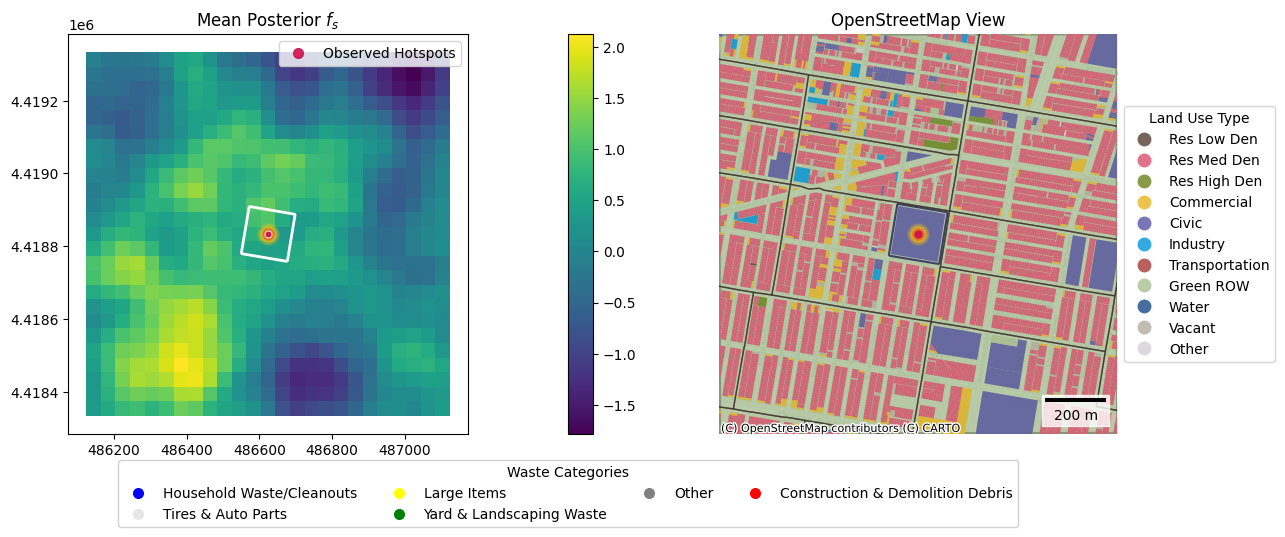

In [62]:
# Cleaner plotting code using helper functions
model.plot_spatial(include_cov=False)

# Setup figure and axes
fig = plt.gcf()
axes = fig.get_axes()
fig.delaxes(axes[1])  # Remove right subplot
axes[0].set_position([0.1, 0.1, 1, 0.8])

# Get limits from left subplot
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

# Plot park boundaries on spatial axis
all_parks_gdf.plot(ax=axes[0], edgecolor='white', facecolor='none', linewidth=2)
philly_border.plot(ax=axes[0], edgecolor='darkgray', facecolor='none', linewidth=2)

# Plot hotspots on spatial axis
plot_hotspots_with_halo(axes[0], dumping_hotspot_gdf, xlim, ylim, crs_26918=True)

# Plot focus group points on spatial axis
plot_focus_group_points(axes[0], focus_group_gdfs, xlim, ylim, markersize=9, crs_26918=True)

# Set limits and add legend
axes[0].set_xlim(xlim)
axes[0].set_ylim(ylim)
legend_handle = Line2D([0], [0], marker='o', linestyle='None', 
                      color='#D0104C', markerfacecolor='#D0104C',
                      markersize=7, alpha=0.9, label='Observed Hotspots')
axes[0].legend(handles=[legend_handle], loc='upper right')

# Setup OSM axis
osm_ax = setup_osm_axis(fig, position=[1, 0.1, 0.5, 0.8])

# Transform data to 3857 for OSM
osm_box, philly_2023_3857, all_parks_3857, land_use_3857 = transform_to_3857(
    all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name],
    philly_2023,
    all_parks_gdf,
    land_use_current
)

# Plot boundaries and land use on OSM axis
plot_boundaries(osm_ax, philly_2023_3857, all_parks_3857, osm_box)
plot_land_use(osm_ax, land_use_3857, use_color)

# Plot hotspots on OSM axis (need to transform first)
filtered_gdf_26918 = dumping_hotspot_gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
filtered_gdf_3857 = filtered_gdf_26918.to_crs(epsg=3857)
osm_xlim = osm_box.total_bounds[[0, 2]]
osm_ylim = osm_box.total_bounds[[1, 3]]
plot_hotspots_with_halo(osm_ax, filtered_gdf_3857, osm_xlim, osm_ylim, crs_26918=False)

# Plot focus group points on OSM axis
plot_focus_group_points(osm_ax, focus_group_gdfs, osm_xlim, osm_ylim, markersize=9, crs_26918=False)

# Set OSM axis limits and add basemap
osm_ax.set_xlim(osm_xlim)
osm_ax.set_ylim(osm_ylim)
ctx.add_basemap(osm_ax, source=ctx.providers.CartoDB.Positron)

# Add scalebar
add_scalebar(osm_ax)

# Create legend for focus group points
focus_group_legend_handles = []
for group_name in focus_group_gdfs.keys():
    color_mpl = get_color_from_group_name(group_name)
    label = get_label_from_color(group_name)
    handle = Line2D([0], [0], marker='o', linestyle='None',
                   color=color_mpl, markerfacecolor=color_mpl,
                   markersize=9, markeredgecolor='white', markeredgewidth=1,
                   label=label)
    focus_group_legend_handles.append(handle)

# Add legend under the maps (entire figure, not just one axis)
if focus_group_legend_handles:
    fig.legend(
        handles=focus_group_legend_handles,
        loc='lower center',
        bbox_to_anchor=(0.9, -0.1),  # moved to the right by increasing x from 0.5 to 0.7
        framealpha=0.9,
        title='Waste Categories',
        ncol=min(4, len(focus_group_legend_handles)),
        fontsize='medium',
        title_fontsize='medium'
    )

# Add legend to OSM axis (outside the map)
# if focus_group_legend_handles:
#     osm_ax.legend(handles=focus_group_legend_handles, loc='center left', 
#                  bbox_to_anchor=(1.02, 0.5), framealpha=0.9, title='Waste Categories')

plt.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_focus_group.png", dpi=500, bbox_inches='tight')


plt.show()


In [63]:
# Get park polygon
park_polygon = all_boxes_gdf[all_boxes_gdf['PARKNAME']==park_name].geometry.iloc[0]

# Create 25x25 grid
minx, miny, maxx, maxy = park_polygon.bounds
x_coords = np.linspace(minx, maxx, 26)
y_coords = np.linspace(miny, maxy, 26)

grid_cells = []
for i in range(25):
    for j in range(25):
        cell = box(x_coords[i], y_coords[j], x_coords[i+1], y_coords[j+1])
        grid_cells.append(cell)

grid_gdf = gpd.GeoDataFrame({'geometry': grid_cells}, crs=litter_within_park.crs)

# Aggregate Litter Rating by grid (mean)
def get_mean_rating(cell):
    points_in_cell = litter_within_park[litter_within_park.within(cell)]
    if len(points_in_cell) > 0:
        return points_in_cell['Litter Rating'].mean()
    return np.nan



In [64]:
# model.plot_spatial(include_cov=False)

# # Get the current figure and axes ---------------------------------
# fig = plt.gcf()
# axes = fig.get_axes()

# # Remove the right subplot (second axis)
# fig.delaxes(axes[1])

# # Match limits from left subplot
# xlim = axes[0].get_xlim()
# ylim = axes[0].get_ylim()

# # Add this instead
# axes[0].set_position([0.1, 0.1, 1, 0.8])

# all_parks_gdf.plot(ax=axes[0], edgecolor='white', facecolor='none', linewidth=2)
# philly_border.plot(ax=axes[0], edgecolor='darkgray', facecolor='none', linewidth=2)

# # Extract x, y coordinates
# x = filtered_gdf.geometry.x
# y = filtered_gdf.geometry.y


# axes[0].set_xlim(xlim)
# axes[0].set_ylim(ylim)
# axes[0].get_xaxis().set_visible(False)
# axes[0].get_yaxis().set_visible(False)

# ## add litter survey
# litter_survey_ax = fig.add_axes([1, 0.1, 0.6, 0.8])  # [left, bottom, width, height]
# # litter_survey_ax = fig.add_axes([1, 0.1, 0.85, 0.8]) # Right plot: 32% width, starts at 65%


# grid_gdf['litter_rating'] = grid_gdf.geometry.apply(get_mean_rating)

# grid_gdf.plot(ax = litter_survey_ax,column='litter_rating', cmap='viridis', edgecolor='none', 
#               linewidth=0.5, legend=True, missing_kwds={'color': 'lightgray', 'alpha': 0.7})

# all_parks_gdf.plot(ax=litter_survey_ax, edgecolor='white', facecolor='none', linewidth=2)
# philly_border.plot(ax=litter_survey_ax, edgecolor='darkgray', facecolor='none', linewidth=2)

# litter_survey_ax.set_xlim(xlim)
# litter_survey_ax.set_ylim(ylim)
# litter_survey_ax.get_xaxis().set_visible(False)
# litter_survey_ax.get_yaxis().set_visible(False)

# plt.title(f'Litter Rating Grid - {park_name.split("_")[0]}')
# plt.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_litter_rating_grid.png", dpi=500, bbox_inches='tight')

# plt.show()


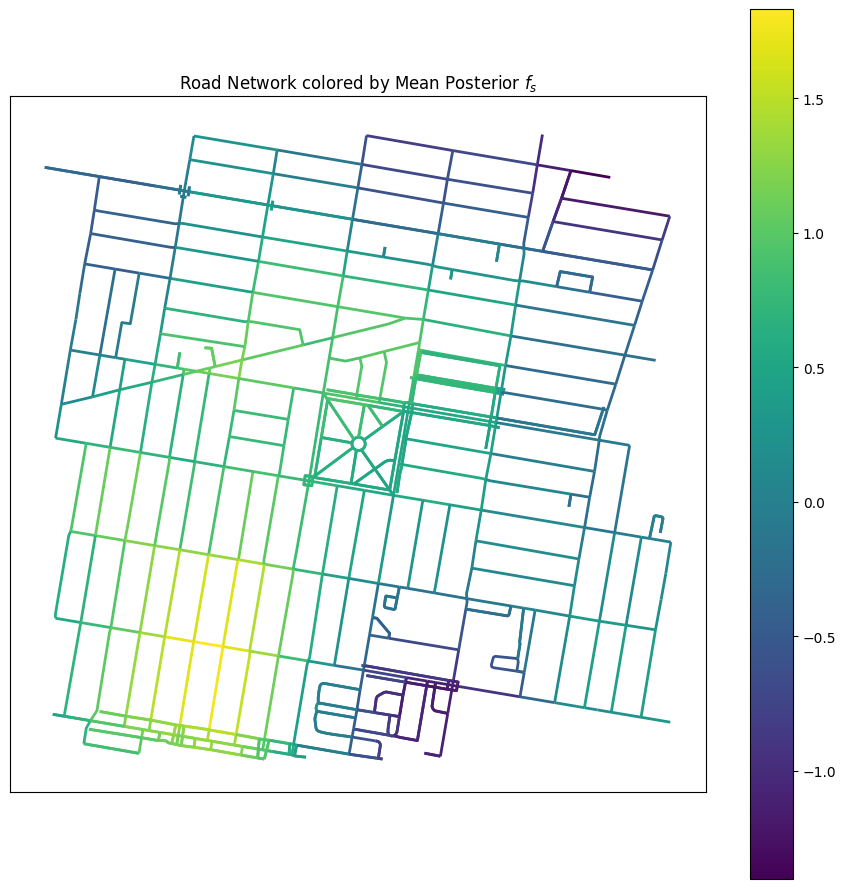

In [65]:

# park_polygon is shapely geometry (Polygon/MultiPolygon)
park_polygon_geom = park_polygon  # or park_polygon.geometry.iloc[0] if it’s a GDF

# pick a CRS source that definitely exists
src_crs = all_boxes_gdf.crs  # or grid_gdf.crs

assert src_crs is not None, "Your source gdf has no CRS; set it first."

park_polygon_ll = (
    gpd.GeoSeries([park_polygon_geom], crs=src_crs)
    .to_crs(epsg=4326)
    .iloc[0]
)

# Extract f_s properly
# f_s_samples = np.array(model.samples['f_xy'])
# #grid_gdf['mean_f_s'] = f_s_samples.mean(axis=0)

# Extract f_s properly - USING MODEL'S GRID DIRECTLY
f_s_samples = np.array(model.samples['f_xy'])
f_s_mean = f_s_samples.mean(axis=0)

# Use model's comp_grid which has the correct ordering
model.comp_grid['mean_f_s'] = f_s_mean

# Spatial join your grid_gdf with model.comp_grid to get the correct values
grid_gdf_with_values = gpd.sjoin(
    grid_gdf[['geometry']], 
    model.comp_grid[['geometry', 'mean_f_s']], 
    how='left', 
    predicate='intersects'
)

# For cells that intersect multiple comp_grid cells, take the mean
grid_gdf['mean_f_s'] = grid_gdf_with_values.groupby(grid_gdf_with_values.index)['mean_f_s'].mean()

# Get road network
G = ox.graph_from_polygon(park_polygon_ll, network_type="all")
edges_gdf = ox.graph_to_gdfs(G, nodes=False)
edges_gdf = edges_gdf.to_crs(grid_gdf.crs)

# Spatial join to assign f_s values to road segments
edges_with_values = gpd.sjoin(edges_gdf, grid_gdf[['geometry', 'mean_f_s']], how='left', predicate='intersects')
edges_colored = edges_with_values.groupby(edges_with_values.index)['mean_f_s'].mean()
edges_gdf['f_s_value'] = edges_colored

# Plot
fig, ax = plt.subplots(figsize=(9, 9))
edges_gdf.plot(ax=ax, column='f_s_value', cmap='viridis', linewidth=2, legend=True, 
               missing_kwds={'color': 'lightgray', 'linewidth': 1})
park_polygon_gdf = gpd.GeoDataFrame([{'geometry': park_polygon}], crs=edges_gdf.crs)
park_polygon_gdf.plot(ax=ax, facecolor='none', edgecolor='white', linewidth=2)
# philly_border.plot(ax=ax, facecolor='none', edgecolor='darkgray', linewidth=2)

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
# # Optional: buildings
# buildings = ox.features_from_polygon(park_polygon, tags={'building': True})
# buildings.to_crs(edges_gdf.crs).boundary.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.3)

ax.set_aspect('equal')
plt.title('Road Network colored by Mean Posterior $f_s$')
plt.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_road_network.png", dpi=500, bbox_inches='tight')

plt.tight_layout()

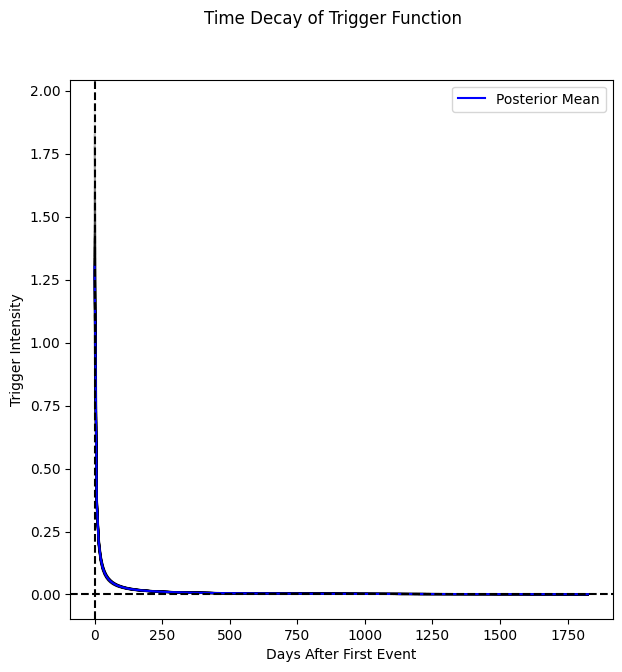

In [66]:
# Save the original plt.show function
original_show = plt.show

# Replace it with a no-op function
plt.show = lambda: None

# Call the function (it won't actually show)
model.plot_trigger_time_decay()

# Get the figure and save it
fig = plt.gcf()
fig.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_trigger_time_decay.png", dpi=500, bbox_inches='tight')

# Restore the original plt.show
plt.show = original_show

# Optionally show it now if you want
# plt.show()


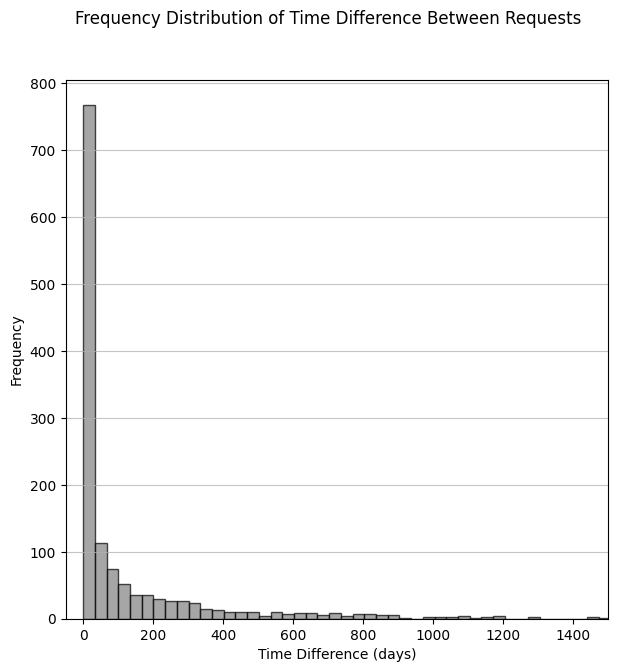

In [67]:
## Delta t distribution ------------------------------------------------------
df = park_points.copy()

# Ensure the 'start_time' column is in datetime format
df['start_time'] = pd.to_datetime(df['start_time'])

# Sort the DataFrame by 'address' and 'start_time'
df.sort_values(by=['address', 'start_time'], inplace=True)

# Group by address and get the next start time
grouped = df.groupby('address')
df['next_start_time'] = grouped['start_time'].shift(-1)

# Calculate the time difference in days
df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# Drop rows where the next start time is missing
df.dropna(subset=['delta_t_days'], inplace=True)


fig,ax = plt.subplots(figsize=(7,7))

# Use the hist() function to plot the frequency distribution of delta_t
ax.hist(df['delta_t_days'], bins=50, edgecolor='black', alpha=0.7, color='gray')

# Set labels and title
fig.suptitle('Frequency Distribution of Time Difference Between Requests')
ax.set_xlim(-50, 1500)
ax.set_xlabel('Time Difference (days)')
ax.set_ylabel('Frequency')
ax.grid(axis='y', alpha=0.75)
#plt.tight_layout()
#plt.savefig('output/decay_mifflin_full.png', dpi=500, bbox_inches='tight')
fig.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_freq_dist.png", dpi=500, bbox_inches='tight')
plt.show() # This will now show the figure after it has been saved


In [68]:
# ## Delta t distribution ------------------------------------------------------
# df = park_points.copy()

# # Ensure the 'start_time' column is in datetime format
# df['start_time'] = pd.to_datetime(df['start_time'])

# # Sort the DataFrame by 'address' and 'start_time'
# df.sort_values(by=['address', 'start_time'], inplace=True)

# # Group by address and get the next start time
# grouped = df.groupby('address')
# df['next_start_time'] = grouped['start_time'].shift(-1)

# # Calculate the time difference in days
# df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# # Drop rows where the next start time is missing
# df.dropna(subset=['delta_t_days'], inplace=True)

# # Create manual bins
# min_val = df['delta_t_days'].min()
# max_val = df['delta_t_days'].max()
# bins = np.linspace(min_val, max_val, 1200)  # 51 edges create 50 bins
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # Print binning information
# num_bins = len(bins) - 1
# bin_width = (max_val - min_val) / num_bins
# actual_time_range = max_val - min_val

# print(f"Number of bins: {num_bins}")
# print(f"Bin width: {bin_width:.4f} days")
# print(f"Actual time range: {actual_time_range:.4f} days (from {min_val:.4f} to {max_val:.4f})")

# # Calculate histogram manually
# counts, _ = np.histogram(df['delta_t_days'], bins=bins)

# # Create the plot
# fig, ax = plt.subplots(figsize=(9,9))

# # Use bar plot instead of hist
# ax.bar(bin_centers, counts, width=np.diff(bins), edgecolor='black', alpha=0.7, color='gray')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests',pad=30)
# ax.set_xlim(-50, 1500)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency')
# ax.grid(axis='y', alpha=0.75)
# plt.tight_layout()
# #plt.savefig('output/delta_t_mifflin.png', dpi=500, bbox_inches='tight')
# plt.show() # This will now show the figure after it has been saved


In [69]:
# Get parameter names
par_names = model.args['t_trig'].get_par_names()  # ['beta', 'gamma']
params_mean = {}

# Calculate mean of posterior samples for each parameter
for name in par_names:
    params_mean[name] = model.samples[name].mean().item()

prior_value = locs_s
tpl = Temporal_Power_Law(prior_value)

# # Step 2: Use your extracted parameters (replace params_mean with your actual variable)
# params_from_model = params_mean  # <-- Replace this with your actual parameter variable
params_from_model = {
    'beta': float(params_mean['beta']),   # Convert array to scalar
    'gamma': float(params_mean['gamma'])  # Convert array to scalar
}

Number of bins: 1199
Bin width: 1.3959 days
Actual time range: 1673.7188 days (from 0.0000 to 1673.7188)
Bin width: 1.4 days
Number of bins: 1046
Time range: 0 to 1460 days
Completed 100/500 iterations
Completed 200/500 iterations
Completed 300/500 iterations
Completed 400/500 iterations
Completed 500/500 iterations


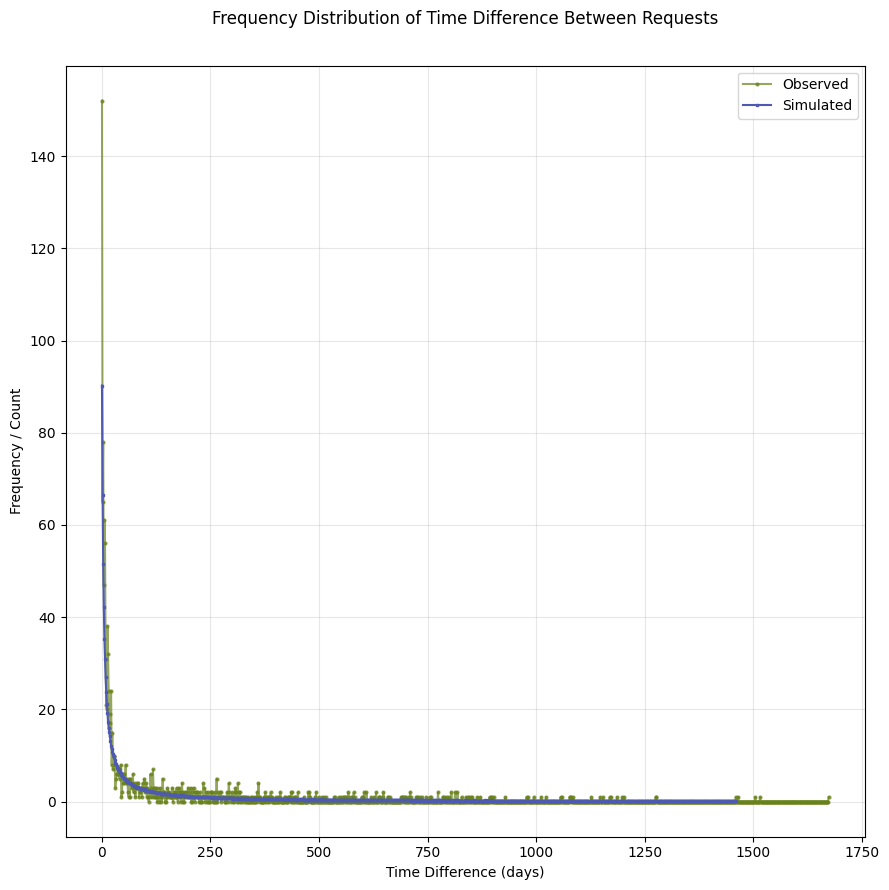

In [70]:
## plot the trigger time distribution (complate observation)------------------------------------------
## Delta t distribution 
df = park_points.copy()

# Ensure the 'start_time' column is in datetime format
df['start_time'] = pd.to_datetime(df['start_time'])

# Sort the DataFrame by 'address' and 'start_time'
df.sort_values(by=['address', 'start_time'], inplace=True)

# Group by address and get the next start time
grouped = df.groupby('address')
df['next_start_time'] = grouped['start_time'].shift(-1)

# Calculate the time difference in days
df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# Drop rows where the next start time is missing
df.dropna(subset=['delta_t_days'], inplace=True)

# Create manual bins
min_val = df['delta_t_days'].min()
max_val = df['delta_t_days'].max()
bins = np.linspace(min_val, max_val, 1200)  # 51 edges create 50 bins
bin_centers_real = (bins[:-1] + bins[1:]) / 2

# Print binning information
num_bins = len(bins) - 1
bin_width = (max_val - min_val) / num_bins
actual_time_range = max_val - min_val

print(f"Number of bins: {num_bins}")
print(f"Bin width: {bin_width:.4f} days")
print(f"Actual time range: {actual_time_range:.4f} days (from {min_val:.4f} to {max_val:.4f})")

# Calculate histogram manually
counts, _ = np.histogram(df['delta_t_days'], bins=bins)

# simulated delta t
# set the scale for rescalring
scale = total_days / 50  # e.g., 1460/50

# First calculate the bin width from your data
data_min = df['delta_t_days'].min()
data_max = df['delta_t_days'].max()
data_range = data_max - data_min
bin_width = data_range / 1200

max_time = 365 * 4  # days
num_bins = int(max_time / bin_width)
bin_edges = np.linspace(0, max_time, num_bins + 1) 

print(f"Bin width: {bin_width:.1f} days")
print(f"Number of bins: {num_bins}")
print(f"Time range: 0 to {max_time} days")

histogram_matrix = []

for i in range(500):
    samples = []
    for j in range(locs_s.shape[0]):
        s = tpl.simulate_trigger(params_from_model)  # already in days
        s_days = s * scale
        samples.append(s_days)             # clip to match bins
    hist_counts, _ = np.histogram(samples, bins=bin_edges)
    histogram_matrix.append(hist_counts)
    if (i + 1) % 100 == 0:
        print(f"Completed {i + 1}/500 iterations")

histogram_matrix = np.array(histogram_matrix)

column_averages = np.mean(histogram_matrix, axis=0)

fig, ax = plt.subplots(figsize=(9,9))

# First dataset - observed data (1199 points)
ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
        color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# Second dataset - simulated data (1518 points) - separate plot call
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.plot(bin_centers, column_averages, marker='s', linestyle='-', 
        color='#4d5aaf', linewidth=1.5, markersize=2, label='Simulated')

# Set labels and title
ax.set_title('Frequency Distribution of Time Difference Between Requests', pad=30)
ax.set_xlabel('Time Difference (days)')
ax.set_ylabel('Frequency / Count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
# plot delta t distribution with log y axis --------------------------------
# fig, ax = plt.subplots(figsize=(9,9))


# # First dataset - observed data (1199 points)
# ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
#         color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# # Second dataset - simulated data (1518 points) - separate plot call
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# ax.plot(bin_centers, column_averages, marker='s', linestyle='-', 
#         color='#4d5aaf', linewidth=1.5, markersize=2, label='Simulated')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests', pad=30)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency / Count')
# ax.set_yscale('log')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

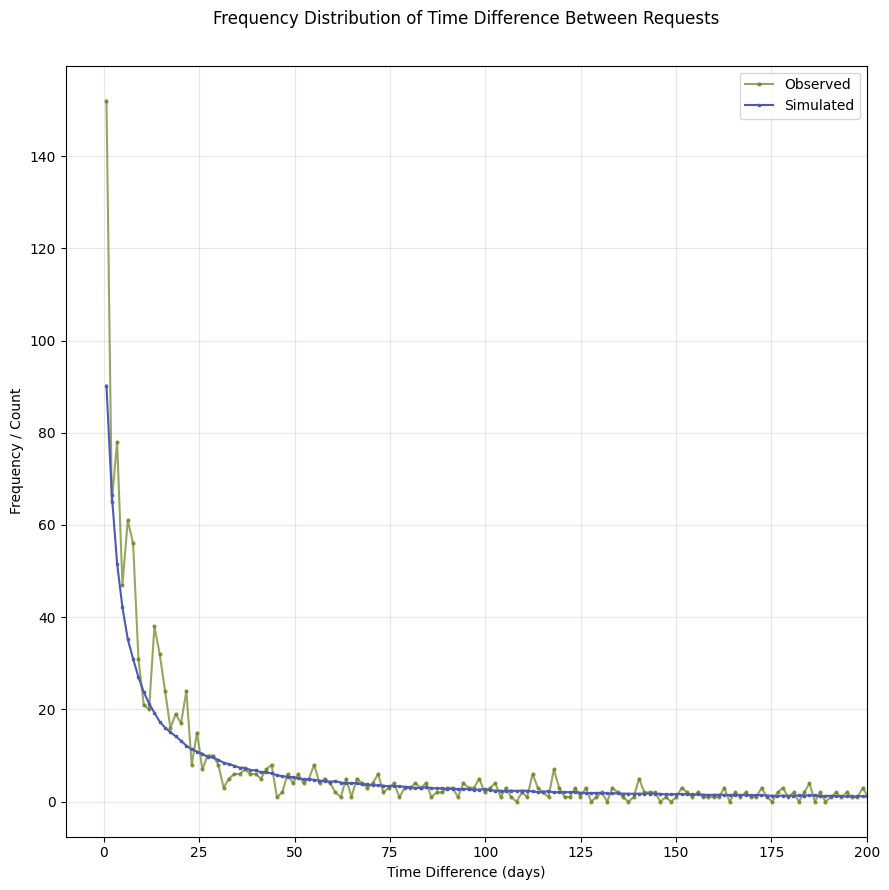

In [72]:
fig, ax = plt.subplots(figsize=(9,9))

# First dataset - observed data (1199 points)
ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
        color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# Second dataset - simulated data (1518 points) - separate plot call
ax.plot(bin_centers, column_averages, marker='s', linestyle='-', 
        color='#4d5aaf', linewidth=1.5, markersize=2, label='Simulated')

# Set labels and title
ax.set_title('Frequency Distribution of Time Difference Between Requests', pad=30)
ax.set_xlabel('Time Difference (days)')
ax.set_ylabel('Frequency / Count')
ax.set_xlim(-10, 200)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'output_litteridx_emb/{park_name.split("_")[0]}_delta_t_200_simulated.png', dpi=500, bbox_inches='tight')

plt.show()

/Users/yuxin/BSTPP/bstpp/main.py:841: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_22683/1910815984.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


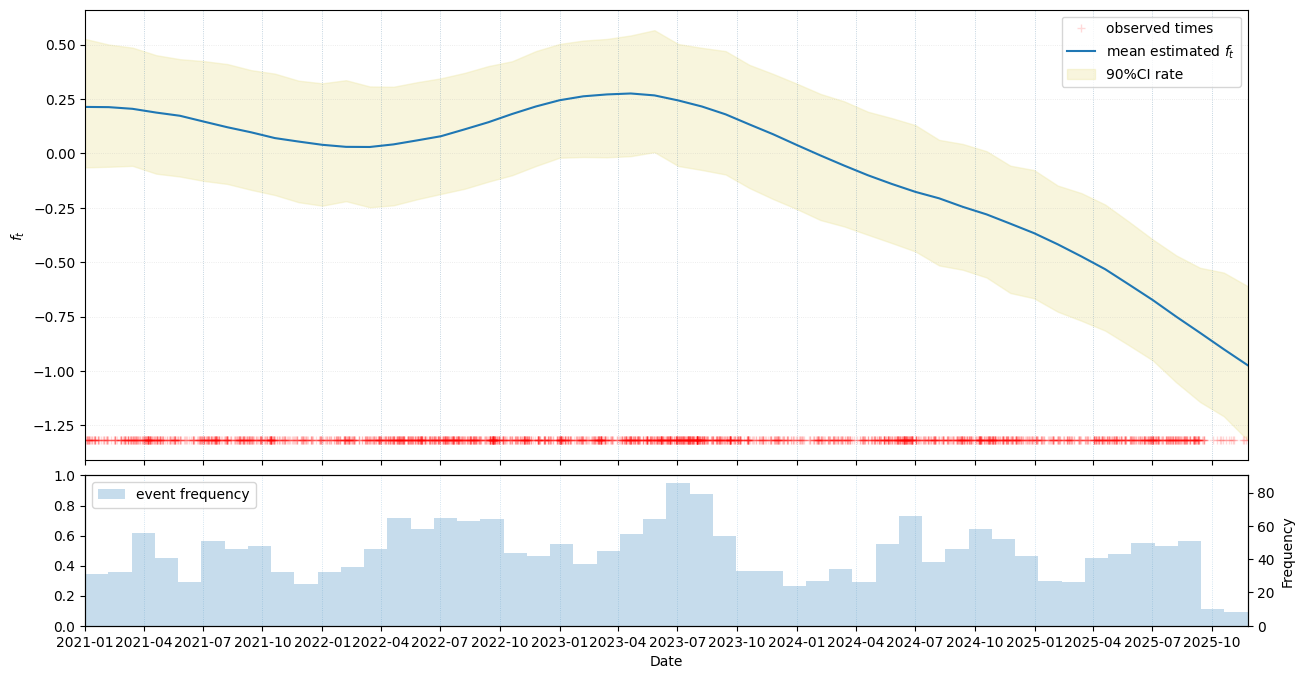

In [73]:
start_date = datetime(2021, 1, 1)  # <-- change this to your real start date

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# Top: GP only
model.plot_temporal_components(
    rescale=True,
    start_date=None,     # IMPORTANT: don't try to do date formatting inside the method
    show_gp=True,
    show_hist=False,
    ax=ax_top
)
ax_top.tick_params(labelbottom=False)
ax_top.set_xlabel("")

# Bottom: histogram only
model.plot_temporal_components(
    rescale=True,
    start_date=None,     # IMPORTANT: we'll format dates ourselves below
    show_gp=False,
    show_hist=True,
    ax=ax_bottom
)

# ----------------------------
# 3) Add calendar month ticks to the SHARED x-axis (bottom axis renders labels)
#    Assumes x-axis is "t in days" starting from start_date
# ----------------------------
x0, x1 = ax_bottom.get_xlim()
x_max = int(np.ceil(x1))

end_date = start_date + pd.Timedelta(days=x_max)

month_starts = pd.date_range(start=start_date, end=end_date, freq="MS")
label_every_n_months = 3
month_starts_labeled = month_starts[::label_every_n_months]

xticks = [(d.to_pydatetime() - start_date).days for d in month_starts_labeled]
xlabels = [d.strftime("%Y-%m") for d in month_starts_labeled]

ax_bottom.set_xticks(xticks)
ax_bottom.set_xticklabels(xlabels)
ax_bottom.set_xlabel("Date")

# Optional: add vertical month gridlines on BOTH panels for alignment
for ax in (ax_top, ax_bottom):
    for d in month_starts_labeled:
        x = (d.to_pydatetime() - start_date).days
        ax.axvline(x, linestyle=":", linewidth=0.6, alpha=0.25)

plt.tight_layout()
plt.savefig(f'output_litteridx_emb/{park_name.split("_")[0]}_temp_full.png', dpi=500, bbox_inches='tight')
plt.show()

/Users/yuxin/BSTPP/bstpp/main.py:1040: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/yuxin/BSTPP/bstpp/main.py:1040: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_22683/805522549.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


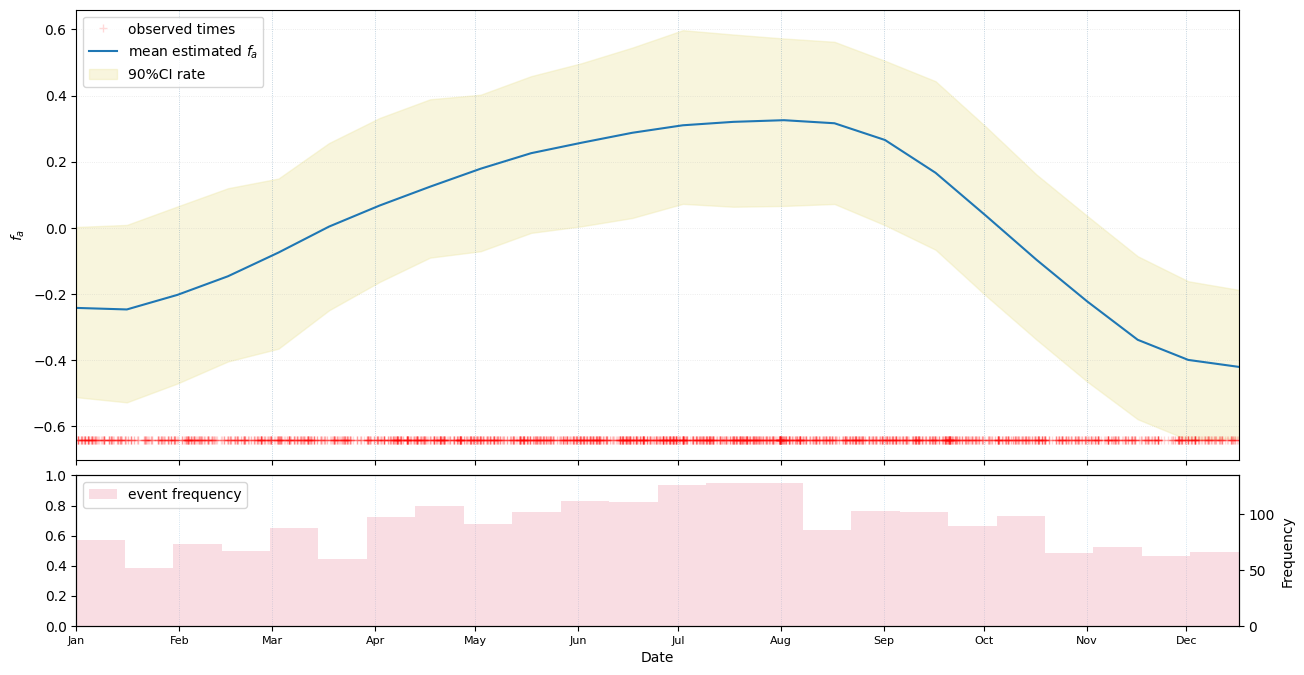

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import calendar

# Set up subplots (similar to temporal example)
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# Top: GP only
model.plot_seasonal_components(
    rescale=True,
    ref_year=2021,  # <-- change this to your reference year if needed
    show_gp=True,
    show_hist=False,
    ax=ax_top
)
ax_top.tick_params(labelbottom=False)
ax_top.set_xlabel("")

# Bottom: histogram only
model.plot_seasonal_components(
    rescale=True,
    ref_year=2021,  # <-- same reference year
    show_gp=False,
    show_hist=True,
    ax=ax_bottom
)

# Optional: add vertical month gridlines on BOTH panels for alignment
ref_year = 2021
offset = model.args['offset_seasonal']
month_days = np.cumsum([0] + [calendar.monthrange(ref_year, m)[1] for m in range(1, 12)])
month_days_offset = (month_days + offset) % model.S
sorted_idx = np.argsort(month_days_offset)
month_starts_labeled = month_days_offset[sorted_idx]

b_scale = model.args["n_s"] / model.S if True else 1.0  # adjust based on your rescale setting
x_a = np.arange(0, model.args["S"], model.args["S"]/model.args["n_s"]) / b_scale

for ax in (ax_top, ax_bottom):
    for x_pos in month_starts_labeled:
        ax.axvline(x_pos, linestyle=":", linewidth=0.6, alpha=0.25)

plt.tight_layout()
plt.savefig(f'output_litteridx_emb/{park_name.split("_")[0]}_seasonal_trend.png', dpi=500, bbox_inches='tight')
plt.show()

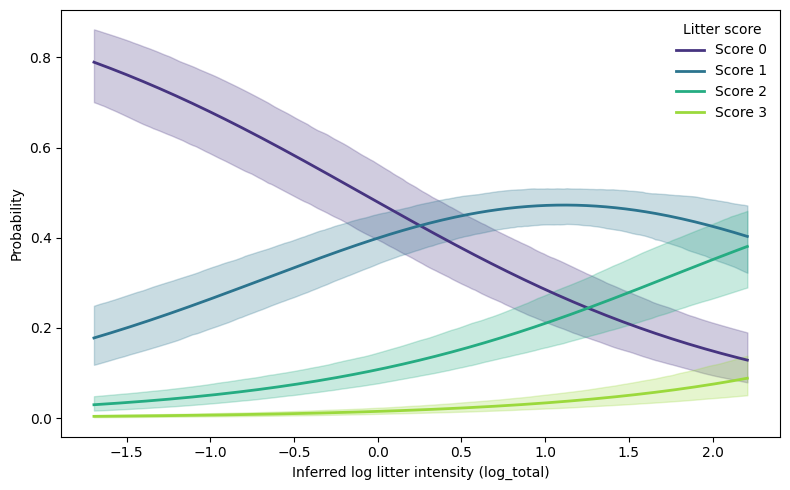

In [75]:
importlib.reload(bstpp.cox_hawkes_shared)
bstpp.cox_hawkes_shared.plot_litter_ordinal_regression(model)

## Test: Clean & Green data

In [76]:
clean_green = pd.read_csv("data/CSVFiles/Clean_Green_Survey_2024_0.csv")
clean_green['survey_start'] = pd.to_datetime(clean_green['survey_start'])

/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_22683/3193275245.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_green['survey_start'] = pd.to_datetime(clean_green['survey_start'])


In [77]:
# First create geometry in WGS84
clean_green_gdf = gpd.GeoDataFrame(
    clean_green,
    geometry=gpd.points_from_xy(clean_green['x'], clean_green['y']),
    crs="EPSG:4326"          # WGS84
)

# --- 2. Project to EPSG:26918 ---
clean_green_26918 = clean_green_gdf.to_crs(epsg=26918)

# Extract projected coordinates
clean_green_26918['X'] = clean_green_26918.geometry.x.astype(float)
clean_green_26918['Y'] = clean_green_26918.geometry.y.astype(float)

# --- 3. Convert rating 1–4 → 0–3 ---
clean_green_26918['score'] = (
    clean_green_26918['Litter Rating'].astype(float).astype(int) - 1
)

# --- 4. Compute T to match the logic used for locs_s ---
min_year = pd.to_datetime(park_points['start_time'].min())
baseline_time = pd.Timestamp(f"{min_year.year}-01-01")

# Days since baseline (same as your locs_s code)
clean_green_26918['T'] = (
    (clean_green_26918['survey_start'] - baseline_time)
    .dt.total_seconds() / (24 * 60 * 60)
)

# day in year
clean_green_26918['A'] = (clean_green_26918['T'] + offset_seasonal) % 365

# --- 5. FILTER LITTER POINTS TO THE MODEL'S SPATIAL DOMAIN ---
park_boundary = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name]

# Ensure boundary is in same CRS (should already be, but safe)
park_boundary = park_boundary.to_crs(epsg=26918)

# Spatial join: keep only litter points inside the park polygon
clean_grenn_within_park = gpd.sjoin(
    clean_green_26918,
    park_boundary,
    how="inner",
    predicate="within"
)

# --- 6. Final dataframe for the model ---
clean_green_for_model = clean_grenn_within_park[['X', 'Y', 'T', 'A', 'score']].copy()
clean_green_for_model = clean_green_for_model[(clean_green_for_model['T'] > 0) & (clean_green_for_model['T'] < np.max(locs_s['T']))]
clean_green_for_model.shape

(217, 5)

Accuracy: 0.6221 (135/217 correct)

Confusion Matrix (rows=true, cols=predicted):
[[103  73   0   0]
 [  9  32   0   0]
 [  0   0   0   0]
 [  0   0   0   0]]


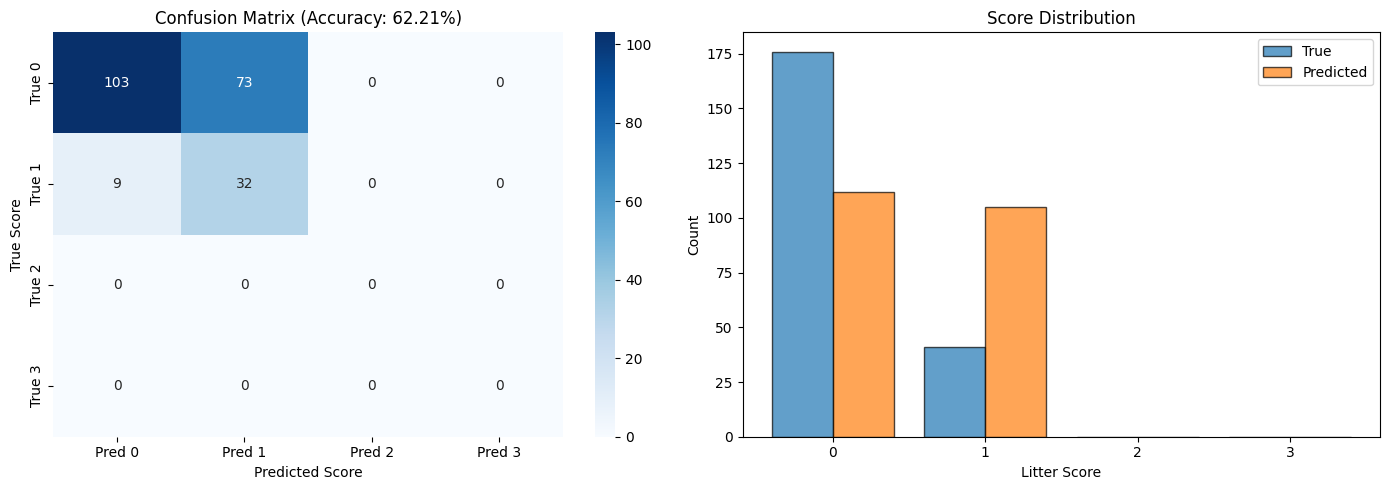


Per-class Accuracy:
  Score 0: 58.52% (176 samples)
  Score 1: 78.05% (41 samples)


In [78]:
import numpy as np
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import seaborn as sns
from bstpp.cox_hawkes_shared import attach_litter_survey_args, hawkes_intensity_sum,ordered_logistic_probs
from bstpp.utils import aligned_difference_cross

# 1. Attach test data
args = attach_litter_survey_args(model, clean_green_for_model, 'score')

# 2. Build hawkes_design (from training events to test events)
window = model.args.get('window', 15)
spatial_window = model.args.get('spatial_window', None)
litter_diff_coords, litter_diff_t_vals, litter_diff_x_vals, litter_diff_y_vals = aligned_difference_cross(
    args['litter_t_events'], args['litter_xy_events'][0], args['litter_xy_events'][1],
    model.args['t_events'], model.args['xy_events'][0], model.args['xy_events'][1],
    window, spatial_window=spatial_window
)
args['litter_hawkes_design'] = {
    "hawkes_i": jnp.asarray(litter_diff_coords[:, 0], dtype=jnp.int32),
    "hawkes_dt": jnp.asarray(litter_diff_t_vals),
    "hawkes_dx": jnp.asarray(litter_diff_x_vals),
    "hawkes_dy": jnp.asarray(litter_diff_y_vals),
    "n_events": args['litter_t_events'].shape[0],
}

# 3. Extract parameters (posterior mean)
samples = model.samples
gamma_l0 = np.mean(samples["gamma_l0"])
gamma_l1 = np.mean(samples["gamma_l1"])
cutpoints = np.cumsum(np.sort(np.mean(samples["cutpoints_unordered"], axis=0)))


# 4. Compute log_total (CORRECTED - compute per sample, then mean)
# Background intensity for each sample: shape [S, N]
log_bg = (
    samples["a_0"][:, None]
    + samples["f_t"][:, args["litter_indices_t"]]
    + samples["f_a"][:, args["litter_indices_a"]]
    + samples["f_xy"][:, args["litter_indices_xy"]]
)

# Hawkes intensity for each sample: shape [S, N]
def hawkes_litter_from_samples(samples, args):
    out = []
    for s in range(samples["alpha"].shape[0]):
        t_pars = {"beta": samples["beta"][s], "gamma": samples["gamma"][s]}
        sp_pars = {"sigmax_2": samples["sigmax_2"][s]}
        out.append(
            hawkes_intensity_sum(
                samples["alpha"][s],
                t_pars,
                sp_pars,
                args['litter_hawkes_design']["hawkes_i"],
                args['litter_hawkes_design']["hawkes_dt"],
                args['litter_hawkes_design']["hawkes_dx"],
                args['litter_hawkes_design']["hawkes_dy"],
                args["t_trig"],
                args["sp_trig"],
                args['litter_hawkes_design']["n_events"],
            )
        )
    return jnp.stack(out)

l_hawkes = jnp.clip(hawkes_litter_from_samples(samples, args), 1e-12)

# Combined intensity per sample: shape [S, N]
log_total = jax.nn.logsumexp(
    jnp.stack([log_bg, jnp.log(l_hawkes)]), axis=0
)

# NOW take the mean: shape [N]
log_total_mean = np.mean(log_total, axis=0)

# # 5. Predict (same as model)
# eta = np.clip(gamma_l0 + gamma_l1 * log_total, -20, 20)
# probs = ordered_logistic_probs(jnp.asarray(eta)[None, :], jnp.asarray(cutpoints)[None, :])[0]
# y_pred = np.argmax(probs, axis=1)

# 5. Predict (same as model)
eta = np.clip(gamma_l0 + gamma_l1 * log_total_mean, -20, 20)  # Use log_total_mean!
probs = ordered_logistic_probs(
    jnp.asarray(eta)[None, :], 
    jnp.asarray(cutpoints)[None, :]
)[0]
y_pred = np.argmax(probs, axis=1)

# 6. Accuracy and Confusion Matrix
y_true = args['litter_score']
accuracy = np.mean(y_pred == y_true)
print(f"Accuracy: {accuracy:.4f} ({np.sum(y_pred == y_true)}/{len(y_pred)} correct)")

# Confusion Matrix
K = probs.shape[1]
confusion = np.zeros((K, K), dtype=int)
for i in range(len(y_true)):
    confusion[y_true[i], y_pred[i]] += 1

print("\nConfusion Matrix (rows=true, cols=predicted):")
print(confusion)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'Pred {i}' for i in range(K)],
            yticklabels=[f'True {i}' for i in range(K)])
axes[0].set_xlabel('Predicted Score')
axes[0].set_ylabel('True Score')
axes[0].set_title(f'Confusion Matrix (Accuracy: {accuracy:.2%})')

# Prediction Distribution
axes[1].hist([y_true, y_pred], bins=np.arange(K+1)-0.5, 
             label=['True', 'Predicted'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Litter Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Score Distribution')
axes[1].legend()
axes[1].set_xticks(range(K))

plt.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_clean_green_pred.png", dpi=500, bbox_inches='tight')


plt.tight_layout()
plt.show()

# Print per-class accuracy
print("\nPer-class Accuracy:")
for k in range(K):
    mask = y_true == k
    if mask.sum() > 0:
        class_acc = np.mean(y_pred[mask] == y_true[mask])
        print(f"  Score {k}: {class_acc:.2%} ({mask.sum()} samples)")

Accuracy: 0.4943 (259/524 correct)

Confusion Matrix (rows=true, cols=predicted):
[[120 102   0   0]
 [ 86 139   0   0]
 [  9  59   0   0]
 [  2   7   0   0]]


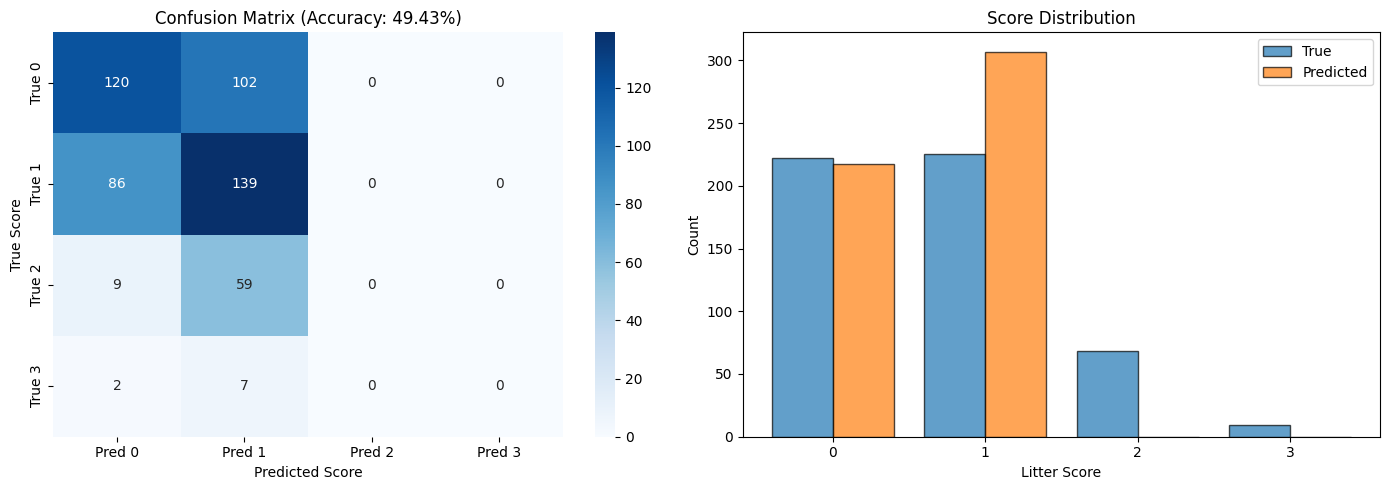


Per-class Accuracy:
  Score 0: 54.05% (222 samples)
  Score 1: 61.78% (225 samples)
  Score 2: 0.00% (68 samples)
  Score 3: 0.00% (9 samples)


In [79]:
# 1. Attach test data
args = attach_litter_survey_args(model, litter_df_for_model, 'score')

# 2. Build hawkes_design (from training events to test events)
window = model.args.get('window', 15)
spatial_window = model.args.get('spatial_window', None)
litter_diff_coords, litter_diff_t_vals, litter_diff_x_vals, litter_diff_y_vals = aligned_difference_cross(
    args['litter_t_events'], args['litter_xy_events'][0], args['litter_xy_events'][1],
    model.args['t_events'], model.args['xy_events'][0], model.args['xy_events'][1],
    window, spatial_window=spatial_window
)
args['litter_hawkes_design'] = {
    "hawkes_i": jnp.asarray(litter_diff_coords[:, 0], dtype=jnp.int32),
    "hawkes_dt": jnp.asarray(litter_diff_t_vals),
    "hawkes_dx": jnp.asarray(litter_diff_x_vals),
    "hawkes_dy": jnp.asarray(litter_diff_y_vals),
    "n_events": args['litter_t_events'].shape[0],
}

# 3. Extract parameters (posterior mean)
samples = model.samples
gamma_l0 = np.mean(samples["gamma_l0"])
gamma_l1 = np.mean(samples["gamma_l1"])
cutpoints = np.cumsum(np.sort(np.mean(samples["cutpoints_unordered"], axis=0)))

# # 4. Compute log_total (same as model does)
# log_bg = (
#     np.mean(samples["a_0"]) +
#     np.mean(samples["f_t"], axis=0)[args['litter_indices_t']] +
#     np.mean(samples["f_a"], axis=0)[args.get('litter_indices_a')] +
#     np.mean(samples["f_xy"], axis=0)[args['litter_indices_xy']]
# )

# t_pars = {"beta": np.mean(samples["beta"]), "gamma": np.mean(samples["gamma"])}
# sp_pars = {"sigmax_2": np.mean(samples["sigmax_2"])}
# l_hawkes = hawkes_intensity_sum(
#     np.mean(samples["alpha"]), t_pars, sp_pars,
#     args['litter_hawkes_design']["hawkes_i"],
#     args['litter_hawkes_design']["hawkes_dt"],
#     args['litter_hawkes_design']["hawkes_dx"],
#     args['litter_hawkes_design']["hawkes_dy"],
#     model.args["t_trig"], model.args["sp_trig"],
#     args['litter_hawkes_design']["n_events"],
# )
# l_hawkes = jnp.clip(l_hawkes, 1e-12)

# log_total = jax.nn.logsumexp(jnp.stack([log_bg, jnp.log(l_hawkes)]), axis=0)

# 4. Compute log_total (CORRECTED - compute per sample, then mean)
# Background intensity for each sample: shape [S, N]
log_bg = (
    samples["a_0"][:, None]
    + samples["f_t"][:, args["litter_indices_t"]]
    + samples["f_a"][:, args["litter_indices_a"]]
    + samples["f_xy"][:, args["litter_indices_xy"]]
)

# Hawkes intensity for each sample: shape [S, N]
def hawkes_litter_from_samples(samples, args):
    out = []
    for s in range(samples["alpha"].shape[0]):
        t_pars = {"beta": samples["beta"][s], "gamma": samples["gamma"][s]}
        sp_pars = {"sigmax_2": samples["sigmax_2"][s]}
        out.append(
            hawkes_intensity_sum(
                samples["alpha"][s],
                t_pars,
                sp_pars,
                args['litter_hawkes_design']["hawkes_i"],
                args['litter_hawkes_design']["hawkes_dt"],
                args['litter_hawkes_design']["hawkes_dx"],
                args['litter_hawkes_design']["hawkes_dy"],
                args["t_trig"],
                args["sp_trig"],
                args['litter_hawkes_design']["n_events"],
            )
        )
    return jnp.stack(out)

l_hawkes = jnp.clip(hawkes_litter_from_samples(samples, args), 1e-12)

# Combined intensity per sample: shape [S, N]
log_total = jax.nn.logsumexp(
    jnp.stack([log_bg, jnp.log(l_hawkes)]), axis=0
)

# NOW take the mean: shape [N]
log_total_mean = np.mean(log_total, axis=0)

# 5. Predict (same as model)
# eta = np.clip(gamma_l0 + gamma_l1 * log_total, -20, 20)
# probs = ordered_logistic_probs(jnp.asarray(eta)[None, :], jnp.asarray(cutpoints)[None, :])[0]
# y_pred = np.argmax(probs, axis=1)
# 5. Predict (same as model)
eta = np.clip(gamma_l0 + gamma_l1 * log_total_mean, -20, 20)  # Use log_total_mean!
probs = ordered_logistic_probs(
    jnp.asarray(eta)[None, :], 
    jnp.asarray(cutpoints)[None, :]
)[0]
y_pred = np.argmax(probs, axis=1)

# 6. Accuracy and Confusion Matrix
y_true = args['litter_score']
accuracy = np.mean(y_pred == y_true)
print(f"Accuracy: {accuracy:.4f} ({np.sum(y_pred == y_true)}/{len(y_pred)} correct)")

# Confusion Matrix
K = probs.shape[1]
confusion = np.zeros((K, K), dtype=int)
for i in range(len(y_true)):
    confusion[y_true[i], y_pred[i]] += 1

print("\nConfusion Matrix (rows=true, cols=predicted):")
print(confusion)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'Pred {i}' for i in range(K)],
            yticklabels=[f'True {i}' for i in range(K)])
axes[0].set_xlabel('Predicted Score')
axes[0].set_ylabel('True Score')
axes[0].set_title(f'Confusion Matrix (Accuracy: {accuracy:.2%})')

# Prediction Distribution
axes[1].hist([y_true, y_pred], bins=np.arange(K+1)-0.5, 
             label=['True', 'Predicted'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Litter Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Score Distribution')
axes[1].legend()
axes[1].set_xticks(range(K))

plt.savefig(f"output_litteridx_emb/{park_name.split("_")[0]}_litter_rating_pred.png", dpi=500, bbox_inches='tight')

plt.tight_layout()
plt.show()

# Print per-class accuracy
print("\nPer-class Accuracy:")
for k in range(K):
    mask = y_true == k
    if mask.sum() > 0:
        class_acc = np.mean(y_pred[mask] == y_true[mask])
        print(f"  Score {k}: {class_acc:.2%} ({mask.sum()} samples)")